---
numbering:
  enumerator: "11.%s"
  equation:
    template: "%s"
---
(chap_genetic)=
# Genetic algorithms for portfolio optimisation and factor investing

<!--
Version: 0.5.6
Last updated: 2026-07-29
Versioning scheme:
  MAJOR: structural overhaul, renumbering of top-level sections
  MINOR: new section, new figure, new table, new content batch
  PATCH: prose tweaks, citation additions, single-bib-entry fixes, typo fixes
See `VERSIONING.md` in the chapter folder for the change log.
-->


## Introduction

### Motivation

Genetic algorithms conclude the sequence of supervised learning methods developed in this part of the book. The models of the preceding chapters, penalised regressions (Chapter 6), tree-based methods (Chapter 7), neural networks (Chapter 8), support vector machines (Chapter 9), and Bayesian methods (Chapter 10), share a common trait with the portfolio-construction, validation, and advanced-topic chapters that follow (Chapters 12 to 20): predictions and portfolio weights are obtained by solving some optimisation problem, whether it be a gradient descent over neural network weights, a quadratic program over portfolio allocations, or a Bayesian posterior computation.

In many practical settings, these optimisation problems are well-behaved. Gradient-based methods converge quickly when losses are smooth and convex, and quadratic programming solves the classical @markowitz1952portfolio mean-variance problem in polynomial time. Yet factor investing, by its very nature, involves selecting among a large number of candidate characteristics, the @fama1993common three-factor model has grown to hundreds of proposed anomalies [@harvey2016and], and the constraints encountered in real-world implementations frequently shatter the convenient properties of standard optimisers:

- **Cardinality constraints.** A portfolio manager may be limited to holding at most $K$ out of $N$ assets. This transforms the continuous quadratic program into a mixed-integer problem that is NP-hard, as established by @Bienstock1996 and @Chang2000.
- **Discrete decisions.** Feature selection (Chapter 5, §5.4.1) involves binary include/exclude choices for each predictor. With $K$ candidate features, the search space has $2^K$ possible subsets, which for $K=122$ (the size of our dataset) is astronomically large.
- **Non-convex objectives.** Maximising the Sharpe ratio, the Sortino ratio, or the Calmar ratio directly does not yield convex programs.
- **Multiple competing objectives.** A systematic investor simultaneously seeks high returns, low variance, small drawdowns, limited turnover, and perhaps a favourable ESG score. These objectives conflict, and there is no single optimal solution, only a set of trade-offs among them.

Genetic algorithms (GAs) are a family of metaheuristic optimisation methods inspired by biological evolution [@Holland1975; @Goldberg1989]. They maintain a *population* of candidate solutions that evolve over successive *generations* through *selection*, *crossover*, and *mutation* operators, guided by a *fitness function*. Because they do not require gradient information and can naturally handle discrete, combinatorial, and multi-objective problems, they are a natural complement to the gradient-based and Bayesian methods covered earlier in this book. In factor investing specifically, this makes them a natural tool for navigating the *factor zoo*: the several hundred candidate anomalies now documented [@harvey2016and], most of them mutually correlated or fragile out of sample, from which the investor must isolate a compact, robust subset. Much of this chapter can be read as a collection of evolutionary strategies for exactly that search.

In the context of factor investing, GAs have been applied to:

1. **Feature (factor) selection**: choosing which characteristics to include in a predictive model,
2. **Portfolio optimisation under complex constraints**: cardinality limits, round-lot requirements, sector caps,
3. **Hyperparameter tuning**: as an alternative to grid search (Chapter 12, §12.3.2) and Bayesian optimisation (§12.3.3),
4. **Alpha factor discovery**: using genetic programming (GP) to evolve mathematical expressions that predict returns,
5. **Multi-objective portfolio construction**: finding the Pareto front of return vs. risk vs. turnover.

### Historical evolution

The academic literature on GAs in finance spans over three decades. We can identify five broad eras.

**Foundational period (1992 to 1999).** @Bauer1992 were among the first to apply GAs to financial trading strategies. @Arnone1993 extended GA optimisation to the Markowitz portfolio selection framework. The most influential work of this period is that of @Allen1999, published in the *Journal of Financial Economics*. Using genetic programming to evolve technical trading rules for the S\&P 500 (1928 to 1995), they found that GP-evolved rules could identify periods of low volatility and high returns.

**Constraint integration era (2000 to 2010).** @Chang2000 published the landmark study on cardinality-constrained portfolio optimisation, demonstrating that GAs, tabu search, and simulated annealing could solve problems that are intractable for exact solvers when the number of assets exceeds a few dozen. Their benchmark datasets are still used in comparative studies today. @Maringer2003 extended this line of work with a hybrid local search algorithm that combined evolutionary search with exact local improvement steps. During this period, @Deb2002 introduced the NSGA-II algorithm for multi-objective optimisation, which became the dominant method for Pareto-based portfolio construction.

**Factor-explicit era (2009 to 2019).** Research shifted from generic trading rules to explicit factor investing applications. @Huang2012 demonstrated early success with a hybrid GA-SVM stock selection model, using GAs to select both features and SVM hyperparameters simultaneously. @Kakushadze2016 published "101 Formulaic Alphas." @ZhangT2020 developed AutoAlpha, a hierarchical evolutionary algorithm for mining alpha factors with mutual information filtering to reduce redundancy. Concurrently, Bailey and López de Prado introduced the Deflated Sharpe Ratio, or DSR [@bailey2014deflated], and @bailey2017probability the Probability of Backtest Overfitting (PBO) framework, providing essential tools for assessing whether GA-discovered strategies are genuine or artifacts of data mining.

**Deep learning integration era (2020 to 2023).** @Liu2020 demonstrated that GP directly maximising the Sharpe ratio doubled performance compared to LASSO and neural network approaches in U.S. cross-sectional returns. Neuroevolution, evolving neural network architectures with methods such as NEAT [@Stanley2002] and EXAMM [@Lyu2024], emerged as a way to automate the architectural choices discussed in Chapter 8. @Yu2023 introduced AlphaGen, which uses proximal policy optimisation (PPO), a reinforcement learning method discussed in Chapter 20, to generate synergistic formulaic alpha collections, outperforming GP-based approaches in the KDD 2023 benchmark. @Olorunda2024 provide a decade-spanning systematic survey confirming that GA-ML hybrids remain the dominant paradigm for stock market prediction.

**LLM-evolutionary era (2024 to present).** The most recent wave combines large language models with evolutionary search. Alpha-GPT [@wang2023alphagpt] pioneered human-AI interactive alpha mining via prompt engineering coupled with a GP-based search engine. Alpha-GPT 2.0 [@Yuan2024] extended this with specialised LLM agents for mining, modelling, and analysis. AlphaForge [@Shi2025] introduced a generative-predictive neural network that mines alpha factors and dynamically combines them with time-varying weights. AlphaAgent [@tang2025alphaagent] demonstrated autonomous alpha mining with regularised exploration, achieving 11% annual excess return on the CSI 500, by incorporating AST-based originality enforcement and complexity control to counteract alpha decay. @Han2026 pushed the frontier further with QuantaAlpha by treating each mining run as a trajectory and applying trajectory-level mutation and crossover operations, achieving an IC of 0.15 with strong cross-market transfer. @ZhangJ2025 provide the first comprehensive survey of LLM-based alpha mining from an agentic perspective, identifying key challenges including limited numerical understanding, lack of diversity, weak exploration dynamics, and temporal data leakage. This rapid evolution (from hand-crafted rules in the 1990s, to population-based search in the 2000s, to neural architecture evolution in the 2020s, to LLM-guided discovery from 2024 onwards) underscores both the vitality of evolutionary methods in finance and the importance of rigorous validation (§11.7.1) as the pace of discovery accelerates.

## Genetic algorithm fundamentals

### What is a genetic algorithm?

A genetic algorithm is a population-based metaheuristic that solves optimisation problems by mimicking the process of natural selection. The key metaphor maps directly from biology to optimisation:

| Biology | Optimisation |
|---------|-------------|
| Individual organism | Candidate solution |
| Chromosome (genotype) | Encoded representation of a solution |
| Gene | Single element of the encoding |
| Phenotype | Decoded solution |
| Fitness | Objective function value |
| Population | Set of candidate solutions |
| Generation | One iteration of the algorithm |
| Selection | Retaining high-quality solutions |
| Crossover (recombination) | Combining parts of two solutions |
| Mutation | Random perturbation of a solution |

We summarise this mapping in TABLE 11.1.

TABLE 11.1: Mapping between biological evolution and GA optimisation.

The core idea is simple: start with a random population of candidate solutions, evaluate how good each one is (fitness), select the better ones to reproduce, combine them (crossover) and introduce small random changes (mutation), and repeat. Over generations, the population evolves toward better solutions.

Formally, let $\mathbf{x} \in \mathcal{X}$ be a candidate solution in some search space $\mathcal{X}$, and let $f: \mathcal{X} \rightarrow \mathbb{R}$ be the fitness function to maximise. A GA operates on a population $P^{(g)} = \{\mathbf{x}_1^{(g)}, \ldots, \mathbf{x}_N^{(g)}\}$ at generation $g$ and produces $P^{(g+1)}$ through the application of selection, crossover, and mutation operators.

@Holland1975 provided the first theoretical justification for GAs through the *Schema Theorem*. A **schema** is a template that matches a subset of chromosomes: for example, the schema `1**0*1` matches all binary strings with a 1 in positions 1 and 6, a 0 in position 4, and any value elsewhere (where `*` is a wildcard). The theorem states that short, low-order schemata with above-average fitness receive exponentially increasing representation in successive generations. Informally, GAs implicitly evaluate a large number of short 'building blocks' in parallel and combine the best ones. @Goldberg1989 formalised this intuition as the **Building Block Hypothesis**: GAs work well when short, fit schemata can be recombined to form even fitter solutions.

The Building Block Hypothesis is an idealisation. In practice, *epistasis* (interactions between genes) and *deception* (where locally fit building blocks mislead the search toward suboptimal regions) can undermine it. For the financial applications in this chapter, the practical implication is that GAs work best when the fitness contribution of each gene (e.g., whether to include a particular factor) is relatively independent, making the building blocks short and combinable. When strong interactions exist between features, the GA may require larger populations and more generations to discover fit combinations.

### How GAs differ from other optimisers

It is useful to position GAs relative to the optimisation methods encountered in earlier chapters. TABLE 11.2 provides a concise comparison.

| Property | Gradient descent (Ch. 7) | Bayesian opt. (§12.3.3) | Grid/random search (§12.3.2) | Genetic algorithm |
|----------|--------------------------|------------------------|------|-------------------|
| Requires gradient? | Yes | No | No | No |
| Handles discrete variables? | No | With difficulty | Yes | Yes |
| Handles constraints? | Via Lagrangians | Via penalties | Natively | Natively |
| Multi-objective? | Scalarisation needed | Single objective | No | Yes (NSGA-II) |
| Parallelisable? | Limited | Sequential (acquisition) | Fully | Fully |
| Risk of local optima? | High | Low (with GP prior) | None (exhaustive) | Low (population diversity) |
| Computational cost | Low per iteration | High (surrogate model) | Explodes with dimension | Moderate (population × generations) |

TABLE 11.2: Comparison of optimisation methods.

GAs are particularly attractive when: (i) the search space is discrete or mixed, (ii) the objective function is non-differentiable or noisy, (iii) constraints are complex and heterogeneous, and (iv) the user wants a set of diverse solutions rather than a single optimum.

### The GA workflow

The generic GA proceeds as follows:

**Algorithm 11.1: Generic Genetic Algorithm**

```
Input: fitness function f, population size N, number of generations G,
       crossover probability p_c, mutation probability p_m
Output: best solution found

1. Initialise: generate P^(0) = {x_1, ..., x_N} randomly
2. For g = 0, 1, ..., G-1:
   a. Evaluate: compute f(x_i) for all x_i in P^(g)
   b. Select: choose N parents from P^(g) based on fitness
   c. Crossover: for each pair of parents, with probability p_c,
      recombine to produce offspring
   d. Mutate: for each offspring, with probability p_m, apply
      random perturbation
   e. Replace: form P^(g+1) from offspring (possibly retaining
      elite individuals)
3. Return: argmax_{x in P^(G)} f(x)
```

In practice, an *elitism* mechanism ensures that the best individual from generation $g$ is always carried over to generation $g+1$, preventing the loss of the best-known solution.

### Genetic algorithms versus genetic programming

A distinction that is important for financial applications is the one between GAs and genetic programming (GP). In a standard GA, the chromosome has a **fixed length** (for instance, a binary vector of length $K$ for feature selection, or a real vector of length $N$ for portfolio weights). In GP, the chromosome is a **variable-length tree** representing a mathematical expression. The leaves (terminals) are variables or constants, and the internal nodes are operators ($+, -, \times, \div, \log, \text{abs}, \ldots$).

This distinction matters because GP can discover **new factors** by composing elementary data fields, whereas a standard GA can only select or weight factors from a predefined universe. For example, GP might evolve the expression $\text{rank}(\text{close}/\text{delay}(\text{close}, 5)) - \text{rank}(\text{volume}/\text{adv20})$, which is a formulaic alpha of the type catalogued by @Kakushadze2016. We explore this application in §11.4.4.

Because the GP implementation in §11.4.4 relies on several concepts that differ substantially from standard GAs, we provide additional detail here. A GP tree has **internal nodes** drawn from a set of operators (the *function set*, e.g., $+, -, \times$, protected division) and **leaf nodes** drawn from a set of terminals (input variables such as `close`, `volume`, and random constants). Together, these form the **primitive set** that defines the space of expressible programs. For instance, the expression $(x_1 \times x_1) + 2.0$ corresponds to a tree with $+$ at the root, a $\times$ subtree on the left (with $x_1$ as both leaves), and the constant $2.0$ on the right.

A key requirement is the **closure property**: every operator must accept as input any value that another operator or terminal can produce. Division is problematic because it is undefined at zero. The standard remedy is *protected division*, defined as $\text{div}(a, b) = a/b$ if $|b| > \epsilon$ and $0$ otherwise, where $\epsilon$ is a small tolerance. Without this safeguard, randomly generated trees frequently produce runtime errors.

Initial trees are created via a procedure known as *ramped half-and-half* [@Koza1992]: half the population is built as full trees (every branch extends to the maximum depth) and half as grow trees (branches terminate at random depths), with the depth limit varied across the population. This ensures a diverse mix of tree sizes. Over successive generations, trees tend to grow larger without corresponding fitness improvements, a phenomenon called **bloat**. Standard countermeasures include static depth limits (e.g., a maximum depth of 8) and parsimony pressure, which adds a penalty proportional to tree size to the fitness function.

The genetic operators in GP also differ from their GA counterparts (contrast with §11.3.4 and §11.3.5). **Tree crossover** swaps randomly selected subtrees between two parent trees, which is fundamentally different from the segment-swapping crossover used for fixed-length binary strings. **Subtree mutation** replaces a random subtree with a newly generated one. Both operators preserve tree validity because the primitive set enforces closure at every node. We implement these concepts in §11.4.4 using DEAP's `gp` module, which provides tree generation (`genHalfAndHalf`), compilation of trees to callable Python functions (`gp.compile`), and bloat control via `gp.staticLimit`.

### Toy example: a miniature feature-selection GA

Before turning to the full financial applications, let us implement a GA from scratch on the simplest possible financial problem. From a small pool of $L = 14$ candidate features, we search for the binary subset whose equal-weighted composite best predicts next-month returns. Each chromosome is a binary mask (gene $k$ is 1 when feature $k$ is included), and the fitness is the cross-sectional Information Coefficient (IC) of the resulting composite. This is the financial analogue of the classic OneMax benchmark (find the binary string maximising the number of 1s): where OneMax counts the 1s, here we measure predictive power. Crucially, the optimum is no longer the all-ones vector, because redundant or noisy features dilute the composite.

This example illustrates every GA component in a handful of lines, with no external optimisation library: initialisation, fitness evaluation, tournament selection, single-point crossover, bit-flip mutation, and elitism. We begin by assembling the feature pool and the fitness function.

In [ ]:
import numpy as np
import pandas as pd
import random
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── A small pool of 14 candidate features ─────────────────────
data_ml = pd.read_parquet('data/mlfi_us_data.parquet')
data_ml = data_ml.rename(columns={'id': 'stock_id'})
pool = ['mom_252', 'vol_252', 'size_log', 'PB', 'ROE', 'Div_yld',
        'rel_str_252d', 'idio_vol_252d', 'Asset_Turn', 'Current_Ratio',
        'Interest_Coverage', 'kurt_252', 'bb_width', 'Cash_to_Assets']
L = len(pool)            # 14 candidate features

# Cross-sectional z-score each feature, then take an in-sample slice
df = data_ml[data_ml['date'].between('2015-01-01', '2019-12-31')]
df = df.dropna(subset=pool + ['R1M_Usd']).copy()
for f in pool:
    g = df.groupby('date')[f]
    df[f] = ((df[f] - g.transform('mean')) / g.transform('std')).clip(-5, 5).fillna(0)
df = df.sample(n=20000, random_state=SEED)
y = df['R1M_Usd'].values

# Sign each feature by its own IC so the composite does not self-cancel
signs = np.array([np.sign(spearmanr(df[f].values, y)[0]) for f in pool])
signed_z = df[pool].values * signs

def fitness(mask):
    """Cross-sectional IC of the equal-weighted composite of selected features."""
    m = np.asarray(mask, dtype=bool)
    if m.sum() == 0:
        return 0.0
    return spearmanr(signed_z[:, m].mean(axis=1), y)[0]

The genetic operators and the evolution loop are written out in full; this is the same scaffolding that every application later in the chapter delegates to a library.

In [ ]:
# ── GA parameters ────────────────────────────────────────────
POP_SIZE = 20            # Population size
N_GEN = 30               # Number of generations
P_CROSS = 0.9            # Crossover probability
P_MUT = 1.0 / L          # Per-gene mutation probability
TOURN_K = 3              # Tournament size

# ── Initialise population (random binary masks) ──────────────
pop = [np.random.randint(0, 2, size=L) for _ in range(POP_SIZE)]

# ── Tournament selection ─────────────────────────────────────
def tournament(pop, scores, k=TOURN_K):
    idx = random.sample(range(len(pop)), k)
    best = max(idx, key=lambda i: scores[i])
    return pop[best].copy()

# ── Single-point crossover ───────────────────────────────────
def crossover(p1, p2):
    if random.random() < P_CROSS:
        pt = random.randint(1, L - 1)    # Crossover point
        c1 = np.concatenate([p1[:pt], p2[pt:]])
        c2 = np.concatenate([p2[:pt], p1[pt:]])
        return c1, c2
    return p1.copy(), p2.copy()

# ── Bit-flip mutation ────────────────────────────────────────
def mutate(x):
    for i in range(L):
        if random.random() < P_MUT:
            x[i] = 1 - x[i]              # Flip bit
    return x

# ── Evolution loop ───────────────────────────────────────────
best_hist, avg_hist = [], []
for g in range(N_GEN):
    scores = np.array([fitness(x) for x in pop])
    best_hist.append(scores.max())
    avg_hist.append(scores.mean())

    # Elitism: carry over the best individual
    elite = pop[int(np.argmax(scores))].copy()

    # Create next generation
    children = [elite]                    # Elitism slot
    while len(children) < POP_SIZE:
        p1 = tournament(pop, scores)
        p2 = tournament(pop, scores)
        c1, c2 = crossover(p1, p2)
        children.append(mutate(c1))
        if len(children) < POP_SIZE:
            children.append(mutate(c2))
    pop = children

# ── Results ──────────────────────────────────────────────────
final = np.array([fitness(x) for x in pop])
best = pop[int(np.argmax(final))]
selected = [pool[i] for i in range(L) if best[i]]
print(f"Best composite IC: {final.max():.4f}")
print(f"Selected {int(best.sum())} / {L}: {selected}")
print(f"IC of all-{L}-feature composite: {fitness(np.ones(L)):.4f}")

Best composite IC: 0.0466
Selected 8 / 14: ['vol_252', 'size_log', 'PB', 'Div_yld',
  'idio_vol_252d', 'Current_Ratio', 'Interest_Coverage', 'bb_width']
IC of all-14-feature composite: 0.0412


In [ ]:
# ── Convergence plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_hist, label="Best IC", linewidth=2)
ax.plot(avg_hist, label="Average IC", linewidth=1,
        linestyle="--")
ax.set_xlabel("Generation")
ax.set_ylabel("Composite IC")
ax.set_title("Miniature feature-selection GA: convergence")
ax.legend()
plt.tight_layout()
plt.show()

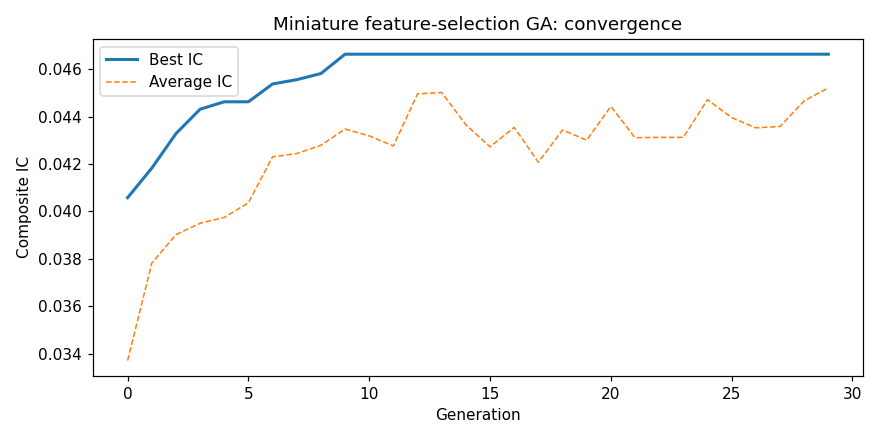

FIGURE 11.1: Convergence of the miniature feature-selection GA. The best composite IC climbs from about 0.041 to 0.047 within roughly nine generations and then plateaus, while the average population IC rises more gradually and noisily, illustrating the balance between exploitation (selection pressure) and exploration (mutation).

As shown in FIGURE 11.1, the GA reliably improves the composite. Two lessons stand out. First, the mechanics are exactly those that recur in every financial application in this chapter: (i) a random population of masks is created, (ii) tournament selection drives the population toward higher-IC subsets, (iii) crossover recombines useful groups of features, and (iv) bit-flip mutation prevents premature convergence. Second, and unlike OneMax, the optimum is not the all-ones vector: the eight-feature subset found by the GA (IC 0.047) beats the fourteen-feature kitchen sink (IC 0.041). The selected features do not simply coincide with the individually highest-IC signals, because the composite rewards diversification: correlated features are partially redundant, so a well-chosen subset can outperform a larger one. This is the essential intuition behind GA feature selection, developed rigorously in §11.4.1 and §11.6.

## GA building blocks

This section examines each component of a GA in detail, with particular attention to the design choices that arise in financial applications.

### Chromosome representation

The choice of encoding determines the structure of the search space. In finance, the most frequent encodings include:

- **Binary encoding.** Each gene $b_j \in \{0, 1\}$ indicates whether feature $j$ is included ($b_j = 1$) or excluded ($b_j = 0$). This is the natural encoding for feature selection problems, where the chromosome is a binary mask of length $K$.

- **Real-valued encoding.** Each gene $w_n \in [0, 1]$ represents the portfolio weight of asset $n$. The chromosome $\mathbf{w} = (w_1, \ldots, w_N)$ must satisfy the budget constraint $\sum_n w_n = 1$. A common approach is to normalise the raw genes: $\hat{w}_n = w_n / \sum_j w_j$.

- **Integer encoding.** Useful for discrete parameters: the number of trees in a random forest, the maximum depth, or time-window lengths for technical indicators.

- **Tree encoding (GP).** Expression trees for alpha factor discovery, where internal nodes are operators ($+, -, \times, \div_{\text{safe}}$) and leaves are market data fields (open, high, low, close, volume) or constants.

We summarise these four encodings, with their gene types, representative applications, and resulting chromosome lengths, in TABLE 11.3.

TABLE 11.3: Common chromosome encodings in quantitative finance.

| Encoding | Gene type | Example application | Chromosome length |
|----------|-----------|--------------------|----|
| Binary | $\{0, 1\}$ | Factor selection | $K$ (number of candidate features) |
| Real-valued | $[0, 1]$ | Portfolio weights | $N$ (number of assets) |
| Integer | $\{1, \ldots, M\}$ | Hyperparameters, time windows | Number of hyperparameters |
| Tree | Variable | Alpha factor discovery | Variable (tree depth) |

### Fitness function design

The fitness function maps a chromosome to a scalar measure of quality. This is arguably the most important design choice in a financial GA, as it determines what the algorithm optimises for.

**Single-objective fitness functions** commonly used in factor investing include:

$$f_{\text{Sharpe}}(\mathbf{w}) = \frac{\hat{\mu}(\mathbf{w}) - r_f}{\hat{\sigma}(\mathbf{w})}, \qquad f_{\text{IC}}(\mathbf{b}) = \text{corr}\big(\hat{y}(\mathbf{b}), r\big), \tag{11.1}$$

where $\hat{\mu}(\mathbf{w})$ and $\hat{\sigma}(\mathbf{w})$ are the estimated mean return and volatility of the portfolio with weights $\mathbf{w}$, and $\hat{y}(\mathbf{b})$ are the model predictions using the features selected by binary mask $\mathbf{b}$.

**Penalised fitness functions** incorporate constraints as soft penalties:

$$f(\mathbf{w}) = \frac{\hat{\mu}(\mathbf{w}) - r_f}{\hat{\sigma}(\mathbf{w})} - \lambda_1 \max\big(0, \|\mathbf{w}\|_0 - K_{\max}\big) - \lambda_2 \cdot \text{turnover}(\mathbf{w}). \tag{11.2}$$

@Liu2020 demonstrate that directly optimising the Sharpe ratio rather than minimising mean squared error produces materially different and economically superior portfolios. This is an important insight: the fitness function should align with the investor's actual objective, not a statistical proxy.

**A warning on noisy fitness.** Financial returns are inherently noisy. A fitness function based on in-sample Sharpe ratios will overfit unless appropriate regularisation is applied. We discuss this challenge extensively in §11.7.1.

### Selection operators

Selection determines which individuals contribute genetic material to the next generation. Three standard mechanisms are:

**Roulette wheel selection.** Each individual is selected with probability proportional to its fitness:

$$p(\mathbf{x}_i) = \frac{f(\mathbf{x}_i)}{\sum_{j=1}^{N} f(\mathbf{x}_j)}. \tag{11.3}$$

This is simple but has drawbacks: it requires non-negative fitness values, and a single dominant individual can monopolise selection, causing premature convergence.

**Tournament selection.** Pick $k$ individuals uniformly at random and select the one with the highest fitness. The parameter $k$ controls selection pressure: $k = 2$ is weak (exploratory), while $k = 5$ or higher is strong (exploitative). Tournament selection is the most widely used method in practice because it does not require global fitness normalisation and is easily parallelised.

**Rank-based selection.** Individuals are sorted by fitness, and selection probability depends on rank rather than absolute fitness value:

$$p(\mathbf{x}_{(i)}) = \frac{2(N - i + 1)}{N(N + 1)},$$

where $\mathbf{x}_{(i)}$ denotes the individual with rank $i$ ($i=1$ is the best). This avoids sensitivity to the scale of the fitness function.

### Crossover operators

Crossover combines genetic material from two parents to produce offspring. The most common operators for binary and real-valued chromosomes are:

**Single-point crossover.** A crossover point $c$ is chosen uniformly in $\{1, \ldots, L-1\}$. The offspring inherit the first $c$ genes from parent 1 and the remaining genes from parent 2. This is the simplest operator but suffers from *positional bias*: genes at the ends of the chromosome are more likely to be disrupted than those in the middle.

**Two-point crossover.** Two points $c_1 < c_2$ are chosen. The segment between them is swapped. This reduces positional bias and better preserves long schemata.

**Uniform crossover.** Each gene is independently inherited from parent 1 with probability $p_0$ (typically 0.5) or from parent 2 with probability $1 - p_0$. This maximises recombination flexibility but can disrupt co-adapted gene groups.

**Arithmetic crossover (real-valued).** For real-valued chromosomes (e.g., portfolio weights):

$$\mathbf{x}_{\text{child}} = \alpha \, \mathbf{x}_{p_1} + (1 - \alpha) \, \mathbf{x}_{p_2}, \qquad \alpha \in [0, 1]. \tag{11.4}$$

This produces offspring that lie on the line segment between the two parents in the solution space. It has a natural financial interpretation: the child portfolio is a blend of two parent portfolios.

### Mutation operators

Mutation introduces random variation to maintain diversity and prevent premature convergence:

**Bit-flip mutation (binary).** Each gene is flipped ($0 \to 1$ or $1 \to 0$) independently with probability $p_m$. A standard choice is $p_m = 1/L$, ensuring approximately one mutation per chromosome per generation.

**Gaussian mutation (real-valued).** A random perturbation drawn from $\mathcal{N}(0, \sigma^2)$ is added to each gene:

$$x'_j = x_j + \epsilon_j, \qquad \epsilon_j \sim \mathcal{N}(0, \sigma^2).$$

The result is clipped to the feasible range $[0, 1]$.

**Subtree mutation (GP).** A randomly chosen subtree of the expression tree is replaced with a newly generated random subtree. This is the GP analogue of bit-flip mutation.

The role of mutation is sometimes underestimated. While crossover is the primary mechanism for combining useful building blocks, mutation is essential for **escaping local optima**, a concern that is especially acute in noisy financial fitness landscapes. Empirical studies suggest that the optimal balance between crossover and mutation rates is problem-dependent and may shift over the course of a run (see the discussion in §11.3.6).

### Key parameters

A GA has several hyperparameters that control its behaviour. We summarise them in TABLE 11.4.

TABLE 11.4: Key GA parameters and their typical ranges.

| Parameter | Symbol | Typical range | Effect of increasing |
|-----------|--------|---------------|---------------------|
| Population size | $N$ | 20 to 500 | More diversity, slower per generation |
| Number of generations | $G$ | 50 to 10,000 | More exploration, higher computation |
| Crossover probability | $p_c$ | 0.6 to 1.0 | More recombination |
| Mutation probability | $p_m$ | 0.001 to 0.1 | More exploration, risk of disruption |
| Tournament size | $k$ | 2 to 7 | Stronger selection pressure |
| Elitism count | $e$ | 1 to 5 | Prevents loss of best solutions |

**Population size** controls the trade-off between diversity and computational cost. For financial feature selection with $K \approx 100$ features, a population of 50 to 100 is usually sufficient. For portfolio optimisation over $N > 500$ assets, larger populations (200 to 500) may be needed.

**Number of generations** depends on the convergence rate. A practical stopping criterion is to halt when the best fitness has not improved for a specified number of generations (e.g., 20).

**Crossover and mutation rates** interact: high crossover with low mutation emphasises exploitation (combining known good building blocks), while the reverse favours exploration (discovering new regions of the search space). We illustrate this trade-off empirically in §11.3.9.

### Demonstration: selection operators compared

We now compare the three selection operators by examining how frequently each individual is chosen from a small population of 20 individuals with varying fitness values. Because this demonstration and the crossover comparison in §11.3.8 concern the mechanics of the operators themselves rather than any particular fitness landscape, we use an illustrative population of fitness values instead of the factor data: the selection probabilities and gene-mixing patterns they reveal are identical whatever the underlying problem.

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)

# Synthetic fitness values for 20 individuals
N_IND = 20
N_SAMPLES = 10_000
fitness_vals = np.linspace(1, 20, N_IND)   # Linearly spaced

# ── Roulette Wheel Selection ─────────────────────────────────
probs_rw = fitness_vals / fitness_vals.sum()
rw_counts = np.random.multinomial(N_SAMPLES, probs_rw)

# ── Tournament Selection (k=3) ───────────────────────────────
tourn_counts = np.zeros(N_IND, dtype=int)
for _ in range(N_SAMPLES):
    idx = random.sample(range(N_IND), 3)
    winner = max(idx, key=lambda i: fitness_vals[i])
    tourn_counts[winner] += 1

# ── Rank-Based Selection ─────────────────────────────────────
ranks = np.arange(1, N_IND + 1)            # Rank 1 (worst) to N (best), matching fitness order
probs_rank = ranks / ranks.sum()
rank_counts = np.random.multinomial(N_SAMPLES, probs_rank)

# ── Sample and plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, counts, title in zip(axes,
    [rw_counts, tourn_counts, rank_counts],
    ["Roulette Wheel", "Tournament (k=3)", "Rank-Based"]):
    ax.bar(range(N_IND), counts / N_SAMPLES, color="steelblue")
    ax.set_xlabel("Individual (sorted by fitness)")
    ax.set_title(title)
axes[0].set_ylabel("Selection frequency")
plt.tight_layout()
plt.show()

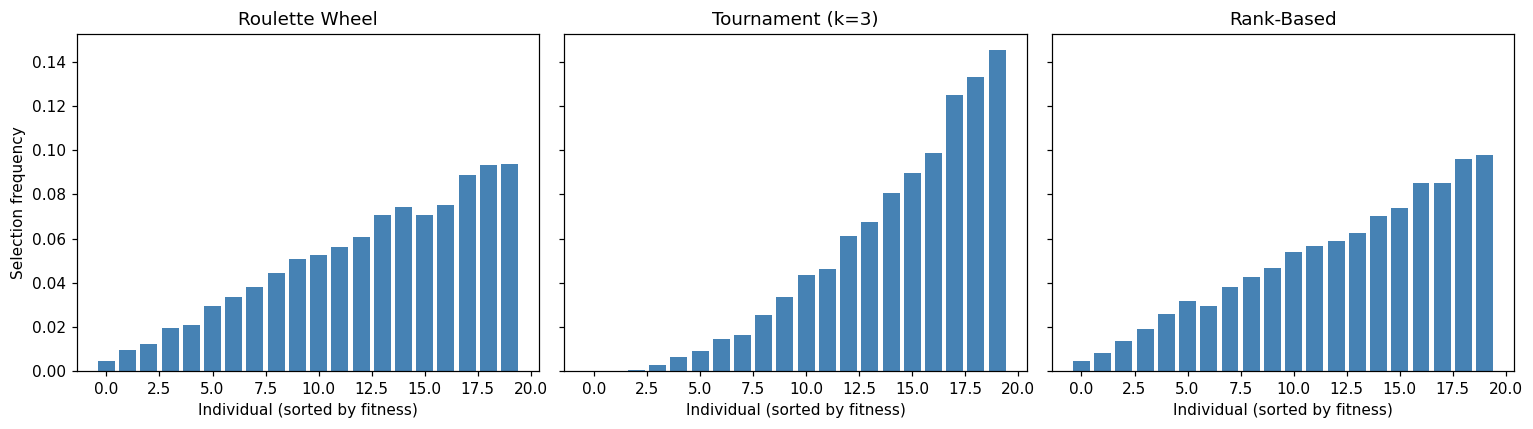

FIGURE 11.2: Selection frequency for 20 individuals (sorted by increasing fitness) under three selection operators. Roulette wheel selection is proportional to absolute fitness, tournament selection concentrates more sharply on the fittest individuals, and rank-based selection depends only on ordinal position.

The results displayed in FIGURE 11.2 confirm that tournament selection offers the most convenient trade-off: it concentrates on high-fitness individuals without the extreme sensitivity to absolute fitness values that roulette wheel exhibits.

### Demonstration: crossover operators compared

To visualise how different crossover operators mix parental genetic material, we generate many children from two fixed parents and plot the resulting distributions.

In [ ]:
L = 20
parent1 = np.zeros(L)          # All zeros
parent2 = np.ones(L)           # All ones
N_CHILDREN = 5_000

def single_point_xo(p1, p2):
    pt = random.randint(1, L - 1)
    return np.concatenate([p1[:pt], p2[pt:]])

def two_point_xo(p1, p2):
    pts = sorted(random.sample(range(1, L), 2))
    child = p1.copy()
    child[pts[0]:pts[1]] = p2[pts[0]:pts[1]]
    return child

def uniform_xo(p1, p2, p=0.5):
    mask = np.random.random(L) < p
    child = np.where(mask, p1, p2)
    return child

def arithmetic_xo(p1, p2, alpha=None):
    if alpha is None:
        alpha = random.random()
    return alpha * p1 + (1 - alpha) * p2

# Generate many children to see the distribution
operators = {
    "Single-point": single_point_xo,
    "Two-point": two_point_xo,
    "Uniform (p=0.5)": uniform_xo,
    "Arithmetic": arithmetic_xo
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (name, op) in zip(axes, operators.items()):
    sums = [op(parent1, parent2).sum() for _ in range(N_CHILDREN)]
    ax.hist(sums, bins=range(L + 2), density=True,
            color="steelblue", edgecolor="white")
    ax.set_title(name)
    ax.set_xlabel("Sum of child genes")
axes[0].set_ylabel("Density")
plt.suptitle("Crossover Operators: Child Gene-Sum Distributions",
             y=1.02)
plt.tight_layout()
plt.show()

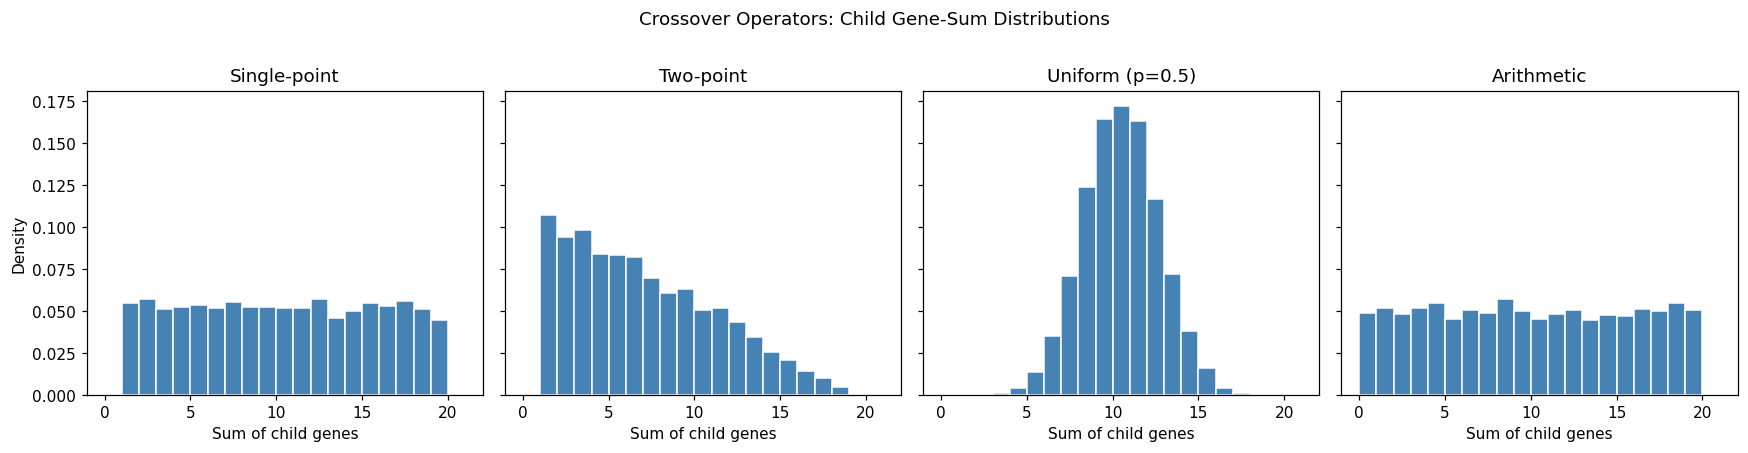

FIGURE 11.3: Distribution of gene sums for children of an all-zeros parent and an all-ones parent. Single-point crossover produces a uniform distribution. Two-point crossover peaks at the extremes (when the swapped segment is short) and in the middle. Uniform crossover produces a binomial distribution centred at $L/2$. Arithmetic crossover yields a continuous uniform distribution on $[0, L]$.

FIGURE 11.3 reveals that the mixing behaviour differs substantially across operators. Uniform crossover is the most disruptive, while arithmetic crossover produces a continuous blend.

### Demonstration: parameter sensitivity

The interplay between population size and mutation rate is critical. We reuse the miniature feature-selection problem of §11.2.5 (its `fitness` function and standardised data), running it with varying settings and measuring convergence speed.

In [ ]:
L = len(pool)            # restore pool size (the §11.3.8 demo reassigned L)

def run_fs_ga(pop_size, p_mut, n_gen=40, seed=42):
    """Run the feature-selection GA, return best-IC history."""
    np.random.seed(seed)
    random.seed(seed)
    pop = [np.random.randint(0, 2, size=L) for _ in range(pop_size)]
    hist = []
    for _ in range(n_gen):
        scores = [fitness(x) for x in pop]
        hist.append(max(scores))
        elite = pop[int(np.argmax(scores))].copy()
        children = [elite]
        while len(children) < pop_size:
            idx = random.sample(range(len(pop)), 3)
            p1 = pop[max(idx, key=lambda i: scores[i])].copy()
            idx = random.sample(range(len(pop)), 3)
            p2 = pop[max(idx, key=lambda i: scores[i])].copy()
            if random.random() < 0.9:
                pt = random.randint(1, L - 1)
                c = np.concatenate([p1[:pt], p2[pt:]])
            else:
                c = p1.copy()
            for j in range(L):
                if random.random() < p_mut:
                    c[j] = 1 - c[j]
            children.append(c)
        pop = children[:pop_size]
    return hist

# ── Experiment 1: Population size ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ps in [10, 20, 50, 100, 200]:
    h = run_fs_ga(pop_size=ps, p_mut=1.0 / L)
    axes[0].plot(h, label=f"N={ps}")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best composite IC")
axes[0].set_title("Effect of population size (p_mut=1/L)")
axes[0].legend()

# ── Experiment 2: Mutation rate ──────────────────────────────
for pm in [0.01, 0.05, 0.07, 0.14, 0.30]:
    h = run_fs_ga(pop_size=50, p_mut=pm)
    axes[1].plot(h, label=f"p_m={pm}")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Best composite IC")
axes[1].set_title("Effect of mutation rate (N=50)")
axes[1].legend()
plt.tight_layout()
plt.show()

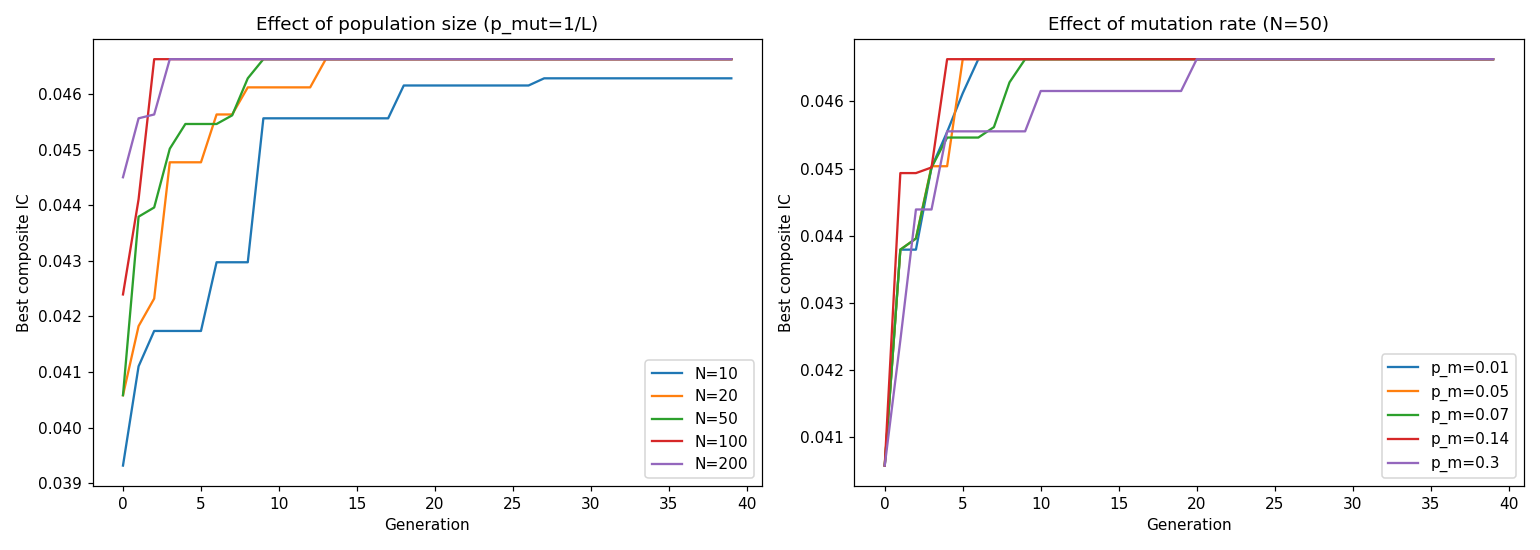

FIGURE 11.4: **Left:** Larger populations converge faster to the optimal composite IC (about 0.047) thanks to greater initial diversity, with $N = 100$ and $N = 200$ almost indistinguishable, showing diminishing returns beyond $N \approx 100$. **Right:** Mutation rates near $1/L$ to $2/L$ (0.07 to 0.14) converge fastest; a very high rate ($p_m = 0.30$) is disruptive and reaches the optimum more slowly, while a very low rate ($p_m = 0.01$) is also slower to escape early plateaus. The intermediate values offer the best trade-off.

The results, shown in FIGURE 11.4, confirm a well-known guideline: a population of 50 to 100 with a mutation rate of $1/L$ to $2/L$ is a robust starting point for binary-encoded problems.

## Applications in factor investing

We now turn to the primary motivation for this chapter: applying GAs across the systematic factor-investing workflow. The four core applications follow that workflow in order: **selecting** which features enter a model (§11.4.1), **constructing** a constrained portfolio from them (§11.4.2), **tuning** the model that maps features to forecasts (§11.4.3), and **discovering** entirely new alpha factors from raw data (§11.4.4). Each is accompanied by a complete code example on the book dataset. A final section (§11.4.5) surveys three research frontiers, trading-rule evolution, neuroevolution, and LLM-GA hybrids, where evolutionary methods are actively reshaping quantitative investing but which sit further from the core feature-selection problem.

### Feature selection with GA

Feature selection was briefly introduced in Chapter 5 (§5.4.1) as a preprocessing step. The challenge is to select, from a universe of $K$ candidate features, a subset that maximises predictive performance while avoiding overfitting. This is a combinatorial problem with $2^K$ possible subsets.

GAs are a natural **wrapper method** for feature selection: each chromosome is a binary mask of length $K$, and the fitness function is the cross-validated performance of a predictive model trained on the selected features. @Dokeroglu2022 conducted a comprehensive survey confirming that GAs are the most widely used metaheuristic for feature selection. @deBarros2024 recently demonstrated the effectiveness of GA-based feature selection specifically for financial time series, achieving improved monotonicity prediction through principled feature subset discovery. Closer still to our own setting, @Kottas2026 couples a GA with a learning-to-rank objective to construct US equity portfolios, ranking stocks on GA-selected characteristics before allocation, a direct analogue of the pipeline we develop in §11.6.

We use the DEAP library (Distributed Evolutionary Algorithms in Python) of @Fortin2012 to implement a GA that selects features for an XGBoost classifier (introduced in Chapter 7). We apply it directly to the book's US equity panel, the full dataset described in §11.6: 122 candidate features and a binary target equal to one when a stock's next-month return exceeds the cross-sectional median for that month. To keep the demonstration fast we draw a random sample of 4,000 stock-months from a 2015 to 2019 in-sample window; the rigorous walk-forward evaluation is deferred to §11.6.

In [ ]:
import numpy as np
import random
import xgboost as xgb
from deap import base, creator, tools, algorithms
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Data: the book US equity panel (see §11.6) ───────────────
data_ml = pd.read_parquet('data/mlfi_us_data.parquet')
data_ml = data_ml.rename(columns={'id': 'stock_id'})
exclude = ['stock_id', 'date', 'R1M_Usd', 'R3M_Usd', 'R6M_Usd',
           'R12M_Usd']
feature_names = [c for c in data_ml.columns if c not in exclude]
n_features = len(feature_names)             # 122 candidate features

# Binary label: beat the cross-sectional median next-month return
win = data_ml[data_ml['date'].between('2015-01-01', '2019-12-31')]
win = win.dropna(subset=['R1M_Usd'])
med = win.groupby('date')['R1M_Usd'].transform('median')
win = win.assign(label=(win['R1M_Usd'] > med).astype(int))
sample = win.sample(n=4000, random_state=SEED)
X = sample[feature_names].values
y = sample['label'].values
feature_names = np.array(feature_names)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Fitness function ─────────────────────────────────────────
def evaluate(individual):
    """CV AUC of XGBoost using selected features."""
    mask = np.array(individual, dtype=bool)
    if mask.sum() == 0:                      # No features selected
        return (0.0,)
    model = xgb.XGBClassifier(
        n_estimators=40, max_depth=3, learning_rate=0.1,
        tree_method="hist", random_state=SEED,
        verbosity=0, n_jobs=-1)
    scores = cross_val_score(
        model, X[:, mask], y, cv=cv, scoring="roc_auc")
    return (scores.mean(),)                  # Must return a tuple

# ── DEAP setup ───────────────────────────────────────────────
# Create fitness and individual types
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat,
                 creator.Individual, toolbox.attr_bool,
                 n=n_features)
toolbox.register("population", tools.initRepeat,
                 list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=1/n_features)
toolbox.register("select", tools.selTournament, tournsize=3)

# ── Run GA ───────────────────────────────────────────────────
pop = toolbox.population(n=24)              # 24 individuals
hof = tools.HallOfFame(1)                   # Track best ever
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", np.max)
stats.register("avg", np.mean)

pop, logbook = algorithms.eaSimple(
    pop, toolbox,
    cxpb=0.7,                               # Crossover probability
    mutpb=0.2,                               # Mutation probability
    ngen=12,                                 # Number of generations
    stats=stats, halloffame=hof, verbose=False)

# ── Results ──────────────────────────────────────────────────
best = hof[0]
mask = np.array(best, dtype=bool)
print(f"Selected {mask.sum()} / {n_features} features")
print(f"Best CV AUC: {best.fitness.values[0]:.4f}")

# ── Compare with using ALL features ──────────────────────────
model_all = xgb.XGBClassifier(
    n_estimators=40, max_depth=3, learning_rate=0.1,
    tree_method="hist", random_state=SEED,
    verbosity=0, n_jobs=-1)
auc_all = cross_val_score(
    model_all, X, y, cv=cv, scoring="roc_auc").mean()
print(f"AUC with ALL features: {auc_all:.4f}")

Selected 60 / 122 features
Best CV AUC: 0.5305
AUC with ALL features: 0.5010


The GA selects 60 of the 122 features and lifts the cross-validated AUC from 0.501 (all features) to 0.530. Two points deserve emphasis. First, the absolute AUC is low: predicting the sign of next-month returns from firm characteristics is genuinely hard, and an AUC near 0.53 is typical for monthly cross-sectional equity classification. Second, and despite this, discarding roughly half the features produces a clear relative improvement, precisely because many of the 122 characteristics are redundant or noisy and the full-feature model dilutes signal with them. The selected subset is dominated by profitability, value, and earnings-quality measures (for example `ROA`, `ROIC`, `EV_EBITDA`, and `REV_Quarterly_Surprise`), together with a handful of liquidity, volatility, and momentum signals (`idio_vol_252d`, `adv_252`, `mom_252`), echoing the factor categories that decades of research have found to matter. This advantage becomes more pronounced when $K$ is large relative to the training sample size, precisely the situation encountered here with 122 characteristics. We caution that this single in-sample window is illustrative only; §11.6 evaluates GA feature selection under a proper walk-forward protocol.

**From selection to weighted composites.** Binary feature selection sits at one end of a continuum. At the other end lies full genetic programming (§11.4.4), which evolves arbitrary expressions over the feature set. In between lies a practical and powerful middle ground: **weighted feature composites**, where the GA simultaneously selects features and assigns them real-valued combination weights. The chromosome becomes a hybrid: a binary gene for inclusion and a continuous gene for the weight of each feature. The arithmetic crossover of Equation (11.4) applies to the weight portion, while bit-flip mutation handles the binary portion. This generalises the binary encoding demonstrated above in a natural way that the DEAP framework supports directly (one need only register two attribute generators, one binary and one float, and concatenate them into a single individual).

Why do weights matter? The equal-weighted composite used in our empirical application (§11.6) treats all selected features as equally informative. In practice, momentum and value signals differ in predictive strength, noise level, and decay rate. @reschenhofer2024combining estimates optimal factor-combination weights for small-cap stocks (roughly 36% value, 28% momentum, 11% profitability, and 5% investment), while cautioning that simple equal-weighting of the factors remains a hard-to-beat benchmark in practice. AlphaGen [@Yu2023] goes further by optimising for *synergy* among factors: the reward signal is the combined portfolio's performance, not individual factor quality. This aligns with the ensemble combination ideas of Chapter 13, where the optimal aggregation of weak learners is rarely uniform.

AlphaForge [@Shi2025] extends this to **time-varying weights**, dynamically adjusting each factor's contribution at each rebalancing date. The resulting composite adapts to market regime changes (the COVID-19 dislocation discussed in §11.6.3 is a case in point). We note that evolving time-varying weights requires either a richer chromosome (one weight per factor per regime) or a two-stage approach: GA for feature selection, followed by a downstream model for dynamic weighting. Exercise 3 at the end of this chapter provides an opportunity to implement the simpler static-weight variant.

### Portfolio optimisation with cardinality constraints

The classical @markowitz1952portfolio mean-variance optimisation selects the portfolio $\mathbf{w}^*$ that minimises variance for a target return, or equivalently maximises the Sharpe ratio:

$$\mathbf{w}^* = \arg\max_{\mathbf{w}} \frac{\mathbf{w}^\top \boldsymbol{\mu} - r_f}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}}, \qquad \text{s.t.} \quad \sum_n w_n = 1, \quad w_n \geq 0. \tag{11.5}$$

This is a quadratic program and can be solved exactly. However, adding a **cardinality constraint** $\|\mathbf{w}\|_0 \leq K_{\max}$ (hold at most $K_{\max}$ assets) renders the problem NP-hard [@Chang2000]. With $N = 500$ assets and $K_{\max} = 30$, the number of possible asset subsets is $\binom{500}{30} \approx 10^{42}$, which is beyond exhaustive enumeration.

A GA handles this naturally. Zhang, Y. et al. (2024) demonstrate that evolutionary approaches (including memetic algorithms that combine GA-based global search with local refinement) outperform classical factor analysis methods for portfolio optimisation under such constraints. Before we proceed to the implementation, it is useful to note that three paradigms for handling constraints in evolutionary algorithms are common in the literature:

- **Penalty functions** add a term to the fitness that penalises constraint violations (as in Equation 11.2 for feature selection). This is flexible but requires tuning the penalty weight $\lambda$: too small and infeasible solutions dominate the population; too large and the search avoids the constraint boundary where optima often lie.
- **Repair operators** project infeasible solutions back into the feasible region after crossover and mutation. Weight normalisation (dividing by the sum) and zeroing-out of small weights are both repair approaches. Repair preserves genetic information while enforcing feasibility, but the projection can introduce bias toward certain regions of the feasible space.
- **Decoder approaches** use an indirect encoding where the chromosome is mapped to a feasible solution by construction. For example, a chromosome of $N$ real values can be decoded to portfolio weights via softmax normalisation, guaranteeing $\sum_n w_n = 1$ and $w_n \geq 0$ without explicit constraints.

In practice, combining repair operators with mild penalty functions is often effective [@Chang2000]. Our implementation below uses repair (normalisation) for the budget constraint and penalty for the cardinality constraint. We encode the chromosome as a real-valued vector of length $N$. Assets with weights below a threshold $\epsilon$ are zeroed out, and the remaining weights are renormalised. The cardinality constraint is enforced by zeroing the smallest weights if too many assets are selected.

In [ ]:
import numpy as np
import random
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Real returns: 30 most liquid stocks, 2015-2019 window ────
import pandas as pd
data_ml = pd.read_parquet('data/mlfi_us_data.parquet')
data_ml = data_ml.rename(columns={'id': 'stock_id'})
win = data_ml[data_ml['date'].between('2015-01-01', '2019-12-31')]
returns = win.pivot_table(index='date', columns='stock_id',
                          values='R1M_Usd').dropna(axis=1)
liq = win.groupby('stock_id')['adv_252'].mean()
top = liq[returns.columns].sort_values(ascending=False).head(30).index
R = returns[top]                          # 30 x 60 monthly return panel

N_ASSETS = 30
K_MAX = 8                                 # Maximum holdings
mu = R.mean().values                      # Mean monthly returns
Sigma = R.cov().values                    # Return covariance matrix
rf = 0.0                                  # Monthly risk-free rate

# ── Fitness function ─────────────────────────────────────────
def evaluate_portfolio(individual):
    """Sharpe ratio with cardinality constraint."""
    w = np.array(individual)
    w = np.maximum(w, 0)                   # Long-only

    # Enforce cardinality: keep only top K_MAX weights
    if (w > 1e-6).sum() > K_MAX:
        threshold = np.sort(w)[-K_MAX]
        w[w < threshold] = 0

    if w.sum() < 1e-10:
        return (-10.0,)                    # Penalise empty portfolio

    w = w / w.sum()                        # Normalise to sum to 1

    port_return = w @ mu
    port_vol = np.sqrt(w @ Sigma @ w)
    sharpe = (port_return - rf) / port_vol if port_vol > 0 else 0
    return (sharpe,)

# ── DEAP setup ───────────────────────────────────────────────
creator.create("FitMax", base.Fitness, weights=(1.0,))
creator.create("Ind", list, fitness=creator.FitMax)

toolbox = base.Toolbox()
toolbox.register("gene", random.random)
toolbox.register("individual", tools.initRepeat,
                 creator.Ind, toolbox.gene, n=N_ASSETS)
toolbox.register("population", tools.initRepeat,
                 list, toolbox.individual)
toolbox.register("evaluate", evaluate_portfolio)
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", tools.mutGaussian,
                 mu=0, sigma=0.1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# ── Run GA ───────────────────────────────────────────────────
pop = toolbox.population(n=100)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", np.max)
stats.register("avg", np.mean)

pop, logbook = algorithms.eaSimple(
    pop, toolbox, cxpb=0.6, mutpb=0.3,
    ngen=80, stats=stats, halloffame=hof, verbose=False)

# ── Extract best portfolio ───────────────────────────────────
best_w = np.array(hof[0])
best_w = np.maximum(best_w, 0)
if (best_w > 1e-6).sum() > K_MAX:
    threshold = np.sort(best_w)[-K_MAX]
    best_w[best_w < threshold] = 0
best_w = best_w / best_w.sum()

print(f"Number of holdings: {(best_w > 1e-6).sum()}")
print(f"Sharpe (monthly): {hof[0].fitness.values[0]:.3f}")
print(f"Expected monthly return: {best_w @ mu:.3%}")
print(f"Monthly volatility: {np.sqrt(best_w @ Sigma @ best_w):.3%}")
print(f"Annualised Sharpe: {hof[0].fitness.values[0] * np.sqrt(12):.3f}")

Number of holdings: 8
Sharpe (monthly): 0.565
Expected monthly return: 2.058%
Monthly volatility: 3.644%
Annualised Sharpe: 1.957


In [ ]:
# ── Plot convergence and portfolio ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence
gen = logbook.select("gen")
fit_max = logbook.select("max")
fit_avg = logbook.select("avg")
axes[0].plot(gen, fit_max, label="Best Sharpe", linewidth=2)
axes[0].plot(gen, fit_avg, label="Avg Sharpe",
             linestyle="--")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Sharpe ratio")
axes[0].set_title("Convergence")
axes[0].legend()

# Portfolio weights
nonzero = best_w > 1e-6
axes[1].bar(np.where(nonzero)[0], best_w[nonzero],
            color="steelblue")
axes[1].set_xlabel("Asset index")
axes[1].set_ylabel("Weight")
axes[1].set_title(f"Optimal Portfolio ({(nonzero).sum()} assets)")
plt.tight_layout()
plt.show()

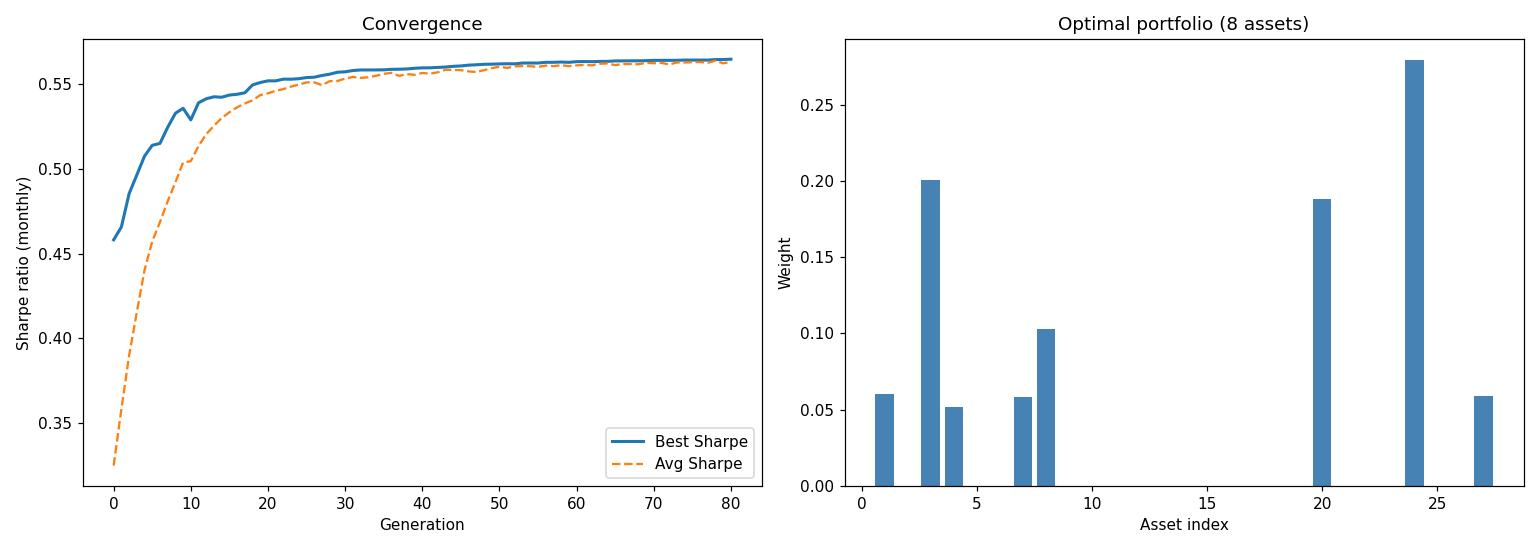

FIGURE 11.5: **Left:** GA convergence for cardinality-constrained portfolio optimisation on 30 real US equities (2015 to 2019). The best monthly Sharpe ratio stabilises well before the 80th generation. **Right:** The optimal portfolio weights, concentrated in 8 of the 30 candidate stocks, as enforced by the cardinality constraint $K_{\max} = 8$.

FIGURE 11.5 illustrates both the convergence dynamics and the resulting portfolio. The GA concentrates the portfolio in exactly $K_{\max} = 8$ of the 30 candidate stocks while achieving a monthly Sharpe ratio of 0.57 (roughly 1.96 annualised). This would be impressive in practice, but it must be viewed with great caution: the expected returns and covariances are estimated in-sample over the same 2015 to 2019 window, so the figure reflects optimisation over realised history rather than genuine out-of-sample skill.

### Hyperparameter tuning with GA

Chapter 12 (§12.3) introduced grid search and Bayesian optimisation for hyperparameter tuning. GAs offer a third approach that is particularly attractive when the hyperparameter space is mixed (some continuous, some discrete, some conditional).

We demonstrate by tuning XGBoost hyperparameters using a GA. The chromosome is a real-valued vector of 10 genes, each representing one hyperparameter normalised to $[0, 1]$ and then mapped to its actual range. We deliberately search a fairly rich space, ten parameters including three regularisation terms, over a long training history (2004 to 2014), because this is the regime in which evolutionary search has a genuine edge over simpler alternatives, as we discuss below.

In [ ]:
import numpy as np
import random
import xgboost as xgb
from deap import base, creator, tools, algorithms
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Book US equity panel; predict the sign of next-month returns
data_ml = pd.read_parquet('data/mlfi_us_data.parquet')
data_ml = data_ml.rename(columns={'id': 'stock_id'})
# 20 characteristics spanning momentum, value, quality, and volatility
features = ['REV_Quarterly_Surprise', 'Buyback_Yield', 'mom_22', 'rsi_14',
            'EPS_Quarterly_Surprise', 'Book_Value_PS', 'vol_22', 'vol_66',
            'Asset_Growth_1Y', 'Div_yld', 'abn_volume_21', 'Net_Income_to_CFO',
            'EPS_FY1_Rev30d', 'skew_252', 'Fixed_Asset_Turnover', 'kurt_252',
            'Sales_Growth_3Y', 'Capex_Intensity', 'FCF_yld', 'rel_str_252d']
win = data_ml[data_ml['date'].between('2004-01-01', '2014-12-31')]
win = win.dropna(subset=features + ['R1M_Usd'])
med = win.groupby('date')['R1M_Usd'].transform('median')
win = win.assign(label=(win['R1M_Usd'] > med).astype(int))
sample = win.sample(n=10000, random_state=SEED)
X = sample[features].values
y = sample['label'].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Hyperparameter space (10 genes, including 3 regularisers) ─
def decode(individual):
    """Map [0,1]^10 genes to XGBoost hyperparameters."""
    g = np.clip(individual, 0, 1)
    return dict(
        n_estimators=int(50 + g[0] * 350),    # 50-400
        max_depth=int(2 + g[1] * 8),           # 2-10
        learning_rate=0.01 + g[2] * 0.29,      # 0.01-0.30
        subsample=0.5 + g[3] * 0.5,            # 0.5-1.0
        colsample_bytree=0.4 + g[4] * 0.6,     # 0.4-1.0
        min_child_weight=int(1 + g[5] * 9),    # 1-10
        reg_alpha=g[6] * 5.0,                  # L1 penalty, 0-5
        reg_lambda=g[7] * 5.0,                 # L2 penalty, 0-5
        gamma=g[8] * 5.0,                      # min split loss, 0-5
        colsample_bylevel=0.4 + g[9] * 0.6     # 0.4-1.0
    )

def evaluate_hp(individual):
    """5-fold CV AUC for decoded hyperparameters."""
    params = decode(individual)
    model = xgb.XGBClassifier(
        **params, tree_method="hist", random_state=SEED,
        verbosity=0, n_jobs=-1)
    scores = cross_val_score(
        model, X, y, cv=cv, scoring="roc_auc")
    return (scores.mean(),)

# ── DEAP setup ───────────────────────────────────────────────
creator.create("FitHP", base.Fitness, weights=(1.0,))
creator.create("IndHP", list, fitness=creator.FitHP)

toolbox = base.Toolbox()
toolbox.register("gene", random.random)
toolbox.register("individual", tools.initRepeat,
                 creator.IndHP, toolbox.gene, n=10)
toolbox.register("population", tools.initRepeat,
                 list, toolbox.individual)
toolbox.register("evaluate", evaluate_hp)
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", tools.mutGaussian,
                 mu=0, sigma=0.15, indpb=0.3)
toolbox.register("select", tools.selTournament, tournsize=3)

# ── Run GA ───────────────────────────────────────────────────
pop = toolbox.population(n=24)
hof = tools.HallOfFame(1)

pop, logbook = algorithms.eaSimple(
    pop, toolbox, cxpb=0.6, mutpb=0.3,
    ngen=40, halloffame=hof, verbose=False)

best_params = decode(hof[0])
print(f"Best CV AUC: {hof[0].fitness.values[0]:.4f}")
print(f"Best hyperparameters: {best_params}")

# ── Random search baseline (matched budget) ──────────────────
best_random = 0
for _ in range(24 * 40):     # Same total evaluations as GA
    ind = [random.random() for _ in range(10)]
    auc = evaluate_hp(ind)[0]
    if auc > best_random:
        best_random = auc
print(f"Best random search AUC: {best_random:.4f}")

Best CV AUC: 0.5335
Best hyperparameters: {'n_estimators': 261, 'max_depth': 8,
  'learning_rate': 0.125, 'subsample': 0.738,
  'colsample_bytree': 0.400, 'min_child_weight': 6,
  'reg_alpha': 3.789, 'reg_lambda': 2.231, 'gamma': 5.000,
  'colsample_bylevel': 0.730}
Best random search AUC: 0.5294


Given the same total budget of fitness evaluations (population $\times$ generations for the GA, an equal number of random trials), the GA attains a cross-validated AUC of 0.534, against 0.529 for random search. The reason the GA wins here, when over a compact space of only a handful of parameters random sampling is famously hard to beat [@bergstra2012random], is dimensionality: with ten hyperparameters the space is sparse enough that a fixed budget of random draws leaves gaps, whereas the GA's crossover and selection exploit the interactions between parameters (for example the interplay of learning rate, tree depth, and the three regularisation terms) to home in on a stronger region. The winning configuration is heavily regularised, a moderate learning rate combined with large `reg_alpha`, `reg_lambda`, and `gamma` penalties and aggressive column subsampling, which is the profile one expects for a high-noise target. The advantage is modest in absolute terms, as it must be at the signal-to-noise ratio of monthly cross-sectional returns, but it is genuine and it widens with the dimensionality of the search, precisely the regime in which a GA repays its extra cost over grid or random search. The more consequential lesson, that the configuration maximising in-sample fitness need not generalise, is developed in §11.6.5, where a naive in-sample fitness overfits, while a fitness aligned with out-of-sample performance lets the GA-tuned model beat its baselines.

### Alpha factor discovery with genetic programming

Genetic programming extends the GA framework from fixed-length vectors to variable-length **expression trees**. In factor investing, GP can discover new formulaic alphas by composing primitive operators and market data fields. This approach was formalised at scale by @Kakushadze2016 with his "101 Formulaic Alphas."

We demonstrate GP by mining a formulaic alpha directly on the book dataset. The terminals are six standardised firm characteristics, the primitives are the four arithmetic operators (with protected division), and the fitness is the cross-sectional **Information Coefficient** (IC): the Spearman rank correlation between the tree's output and the next-month return. Maximising IC is precisely the objective a quantitative researcher cares about.

In [ ]:
import operator
import numpy as np
import pandas as pd
import random
from deap import base, creator, tools, gp, algorithms
from scipy.stats import spearmanr

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -- Data: six standardised features, target = next-month return
data_ml = pd.read_parquet('data/mlfi_us_data.parquet')
data_ml = data_ml.rename(columns={'id': 'stock_id'})
gp_feats = ['mom_252', 'vol_252', 'size_log', 'PB', 'ROE', 'Div_yld']
d = data_ml[data_ml['date'].between('2015-01-01', '2019-12-31')]
d = d.dropna(subset=gp_feats + ['R1M_Usd']).copy()
for f in gp_feats:                          # cross-sectional z-score
    g = d.groupby('date')[f]
    d[f] = ((d[f] - g.transform('mean')) /
            g.transform('std')).fillna(0.0).clip(-5, 5)
Xz = [d[f].values for f in gp_feats]
y = d['R1M_Usd'].values

# -- Protected division (closure) ------------------------------
def safe_div(a, b):
    b = np.asarray(b, dtype=float)
    return np.where(np.abs(b) > 1e-6, a / np.where(b == 0, 1, b), 1.0)

# -- Primitive set: 6 feature terminals + arithmetic -----------
pset = gp.PrimitiveSet("MAIN", arity=len(gp_feats))
pset.addPrimitive(np.add, 2)
pset.addPrimitive(np.subtract, 2)
pset.addPrimitive(np.multiply, 2)
pset.addPrimitive(safe_div, 2)
pset.addEphemeralConstant("rc", lambda: round(random.uniform(-2, 2), 2))
pset.renameArguments(**{f"ARG{i}": nm for i, nm in enumerate(gp_feats)})

# -- DEAP setup: maximise cross-sectional IC -------------------
creator.create("FitIC", base.Fitness, weights=(1.0,))
creator.create("IndTree", gp.PrimitiveTree, fitness=creator.FitIC)

toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate,
                 creator.IndTree, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)

def eval_ic(individual):
    func = toolbox.compile(expr=individual)
    pred = np.asarray(func(*Xz), dtype=float)
    if pred.ndim == 0 or not np.isfinite(pred).all() or pred.std() < 1e-12:
        return (-1.0,)                       # reject degenerate trees
    ic, _ = spearmanr(pred, y)
    return (ic if np.isfinite(ic) else -1.0,)

toolbox.register("evaluate", eval_ic)
toolbox.register("select", tools.selTournament, tournsize=5)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)
toolbox.decorate("mate",
                 gp.staticLimit(operator.attrgetter("height"), 6))
toolbox.decorate("mutate",
                 gp.staticLimit(operator.attrgetter("height"), 6))

# -- Run GP ----------------------------------------------------
pop = toolbox.population(n=200)
hof = tools.HallOfFame(1)
pop, logbook = algorithms.eaSimple(
    pop, toolbox, cxpb=0.7, mutpb=0.2, ngen=25,
    halloffame=hof, verbose=False)

# -- Results ---------------------------------------------------
best_tree = hof[0]
print(f"Discovered alpha: {best_tree}")
print(f"Pooled IC: {best_tree.fitness.values[0]:.4f}")

singles = {f: spearmanr(d[f].values, y)[0] for f in gp_feats}
bf = max(singles, key=lambda k: abs(singles[k]))
print(f"Best single-feature IC: {bf} = {singles[bf]:.4f}")

Discovered alpha: subtract(add(subtract(subtract(PB,
  multiply(add(vol_252, vol_252), 0.24)), size_log), 0.03),
  add(vol_252, Div_yld))
Pooled IC: 0.0446
Best single-feature IC: PB = 0.0248


In [ ]:
import matplotlib.pyplot as plt

func = toolbox.compile(expr=best_tree)
pred = np.asarray(func(*Xz), dtype=float)
dec = pd.qcut(pd.Series(pred).rank(method="first"), 10, labels=False)
mean_ret = pd.Series(y).groupby(dec).mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(mean_ret.index + 1, mean_ret.values, color="steelblue")
ax.set_xlabel("Predicted-alpha decile (1 = low, 10 = high)")
ax.set_ylabel("Mean realised next-month return")
ax.set_title("GP-discovered alpha: monotonicity across deciles")
plt.tight_layout()
plt.show()

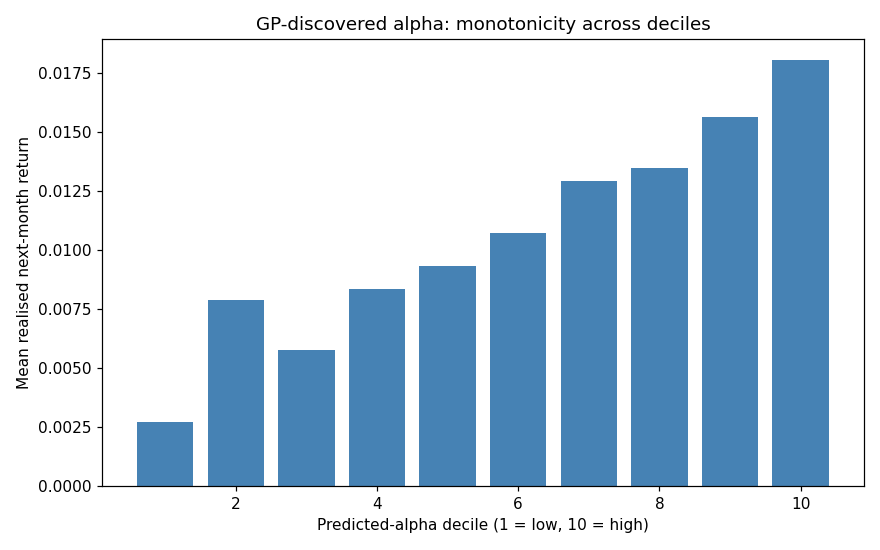

FIGURE 11.6: Mean realised next-month return across deciles of the GP-discovered alpha, computed over the full 2015 to 2019 cross-section (in-sample). The relationship is close to monotone: stocks in the top decile of the evolved formula outperform those in the bottom decile, consistent with the alpha's pooled IC of 0.045.

As FIGURE 11.6 illustrates, the evolved formula produces a near-monotone spread in realised returns across its deciles. The discovered alpha is economically interpretable: after simplification it rewards low valuation (`PB`) and penalises volatility (`vol_252`) and size (`size_log`), a value-and-low-risk tilt of exactly the kind the factor literature documents. Its pooled IC of 0.045 nearly doubles the 0.025 IC of the best single input (`PB`), showing that GP can combine raw characteristics into a stronger composite than any one of them alone. The magnitude is broadly in line with the out-of-sample IC of 0.047 that @Ren2024 report for warm-started GP on Chinese A-shares, though we stress that our 0.045 is in-sample and would shrink under the walk-forward and multiple-testing corrections of §11.7.1. At production scale, the terminal set would additionally include time-series operators (rank, delay, correlation, ts_mean, ts_std) over raw price and volume fields. @Cui2021 formalised this pipeline with AlphaEvolve, a learning framework that combines GP with neural network-based surrogate models to discover novel alphas efficiently. @Yang2024 extended the paradigm by blending GA-generated alpha factors with sentiment features in an ensemble classification framework. @LiQ2024 take a complementary route, feeding GP-discovered symbolic features into an LSTM network to marry the interpretability of formulaic alphas with the sequence-modelling capacity of deep learning. @WangGeng2026 instead make the objective multi-dimensional, evolving factors with a genetic programme whose tri-objective fitness jointly maximises the Sharpe ratio and annualised return while minimising drawdown, re-evolving interpretable factors within a rolling window.

Recent advances have substantially improved the GP alpha mining pipeline:

- **Warm Start GP.** @Ren2024 propose initialising the GP population with carefully chosen structural templates rather than random trees. This *warm start* achieves out-of-sample IC of 0.047 (vs. 0.036 for standard GP) and over 50% annualised returns on Chinese A-shares, demonstrating that domain knowledge injected at initialisation accelerates convergence without sacrificing diversity.

- **Alpha-squared.** @Xu2024 reformulate alpha discovery as a program construction task using deep reinforcement learning with a domain-specific language for trading logic. Their approach introduces dimensional analysis for pruning the search space and ensuring logical soundness of discovered alphas. This offers a principled alternative to the purely stochastic search of GP.

- **AlphaForge.** @Shi2025 propose a two-stage framework: a generative-predictive neural network mines alpha factors (Stage 1), then dynamically combines them with time-varying weights (Stage 2). This leverages deep learning's spatial exploration capabilities while preserving factor diversity (a key concern when building portfolios from multiple alpha signals).

- **Geometric semantic GP.** A recent contribution by @Bunjerdtaweeporn2025 demonstrates that *geometric semantic GP* (in which crossover and mutation operate on the semantics of programs rather than their syntax) provides superior forecast accuracy and portfolio performance for cross-sectional U.S. equity strategies compared to standard GP.

These developments suggest that the GP alpha mining field is maturing from a proof-of-concept stage to a production-grade methodology, though the overfitting concerns discussed in §11.7.1 remain paramount.

**Constrained feature construction.** Between binary feature selection (§11.4.1) and full GP expression trees lies **constructive induction** [@Krawiec2002]: creating new features by applying operators from a finite menu to existing features. In quantitative finance, the operator set typically includes time-series functions (ts_mean, ts_std, ts_delta, ts_rank, ts_corr), cross-sectional operators (rank, z-score, winsorize), and arithmetic combinators (ratio, difference, product). A GA chromosome can encode each constructed feature as a fixed-length tuple (operator, operand_1, operand_2, lookback_period) drawn from this menu. This is far simpler than full GP trees, substantially richer than binary masks, and the fixed-length encoding avoids bloat entirely. @Su2022 demonstrate this approach using 206 quantitative factors as building blocks, with Sharpe ratio and factor correlation as fitness criteria. @Xue2016 provide a comprehensive survey of evolutionary approaches to feature selection and construction, documenting how multi-objective formulations (§11.5) can balance predictive power against feature set complexity.

From a practical standpoint, the `gplearn` library provides an sklearn-compatible implementation of GP-based feature construction via its `SymbolicTransformer` class. It evolves a population of symbolic expressions, selects the best from a hall-of-fame, and filters to the least correlated set. @Tran2019 show that GP-constructed features can reduce dimensionality to less than 4% of the original feature set while improving classification performance. For the factor investing setting, this means GP could compress 122 raw characteristics into 5-10 interpretable composite features, each an explicit formula that practitioners can inspect and validate against economic intuition.

### Frontiers and extensions

The three topics below sit at the research frontier of evolutionary methods in quantitative investing. They are less directly tied to the cross-sectional feature-selection problem that anchors this chapter, and we present them without code, but each is an active area where GAs and their descendants are reshaping practice.

#### Trading strategy evolution

Beyond portfolio weights, GAs can evolve entire trading strategies. The chromosome encodes a set of rules (for example, "buy when the 10-day moving average crosses above the 50-day moving average and RSI is below 30"). This application connects to the seminal work of @Allen1999, who used GP to discover technical trading rules.

In practice, the rules can be encoded as:
- **Threshold-based:** each gene specifies a threshold for a particular indicator (e.g., "RSI < gene_1", "MACD > gene_2"). The chromosome is a fixed-length real-valued vector where each gene maps to a decision boundary.
- **Tree-based (GP):** expression trees combine indicators and logical operators to produce buy/sell signals. Crossover and mutation operate on tree structures rather than vectors.
- **Strongly-typed GP (STGP):** a refinement where separate branches handle different data types (e.g., technical indicators versus sentiment scores), enforcing type safety during evolution. @Christodoulaki2025 introduced STGP-SATA, which uses separate tree branches for technical and sentiment analysis, significantly outperforming MLP, SVM, XGBoost, and LSTM benchmarks across Sharpe ratio and risk metrics.

We note a critical cautionary point: @Allen1999 found that GP-evolved rules identified favourable market conditions but **produced no excess returns after realistic transaction costs**. @Neely1997 found slightly more positive results in FX markets. The lesson for practitioners is that trading strategy evolution requires especially careful out-of-sample validation and realistic cost modelling.

More recent contributions have refined the approach. @Salman2022 and @Salman2025 optimise multi-threshold trading strategies under the *directional changes* paradigm, in which price movements are characterised by their magnitude rather than by fixed time intervals. @Long2025 combine this with multi-objective GP and NSGA-II, evolving strategies that simultaneously optimise total return, expected rate of return, and risk. Their approach is tested on 110 stock datasets from 10 international markets. @Menoita2025 introduce *vectorial GP*, in which operations are performed on vectors of indicator values rather than scalar quantities, and show that strongly-typed vectorial GP consistently outperforms standard GP on multi-year financial instrument data.

In the cryptocurrency space, where transaction costs are lower and markets trade continuously, the results have been more encouraging. A recent framework by @Tian2025 integrates GAs with multi-agent coordination for adaptive crypto trading parameter optimisation. On BTC, ETH, and BNB (5-minute frequency, December 2024 to September 2025), the hybrid framework improved total returns by 29%, 550%, and 169% respectively over standard benchmarks, with enhanced Sharpe and Sortino ratios.

Despite these advances, the fundamental warning of @Allen1999 remains relevant: in liquid equity markets with non-trivial transaction costs, evolved trading rules must clear a high bar to deliver net-of-cost profits. The reader should approach this application with the same scepticism that Chapter 14 (§14.4.2) recommends for any backtest.

#### Neuroevolution: evolving neural network architectures

Chapter 8 treated neural networks as fixed architectures whose weights are optimised via gradient descent. A natural question is: can we also optimise the architecture itself? **Neuroevolution** answers this by using evolutionary algorithms to evolve both the topology and the weights of neural networks. This connects directly to the architectural choices discussed in Chapter 8 (§8.3) (number of layers, neurons, activation functions, connectivity) which are typically made by the user through trial and error or grid search (Chapter 12, §12.3).

Three approaches are particularly relevant for financial applications:

- **NEAT** (NeuroEvolution of Augmenting Topologies; [@Stanley2002]): starts with minimal networks and progressively adds neurons and connections through structural mutation, using a *speciation* mechanism to protect topological innovations from being eliminated before they mature. @HuangLC2025 applied NEAT to stock trading using seven technical indicators (SMA, KD, MACD, CCI, Williams %R, RSI, ADOSC) on 22 years of S&P 500 data (503 stocks, 2000 to 2022). NEAT achieved returns comparable to buy-and-hold but with **significantly lower risk exposure and greater stability**. This suggests that neuroevolution's value may lie more in risk management than in raw return enhancement.

- **EXAMM** (Evolutionary eXploration of Augmenting Memory Models; [@Lyu2024]): extends the NEAT paradigm to recurrent architectures, progressively evolving RNNs with LSTM and GRU memory cells. Applied to stock return prediction across all 30 Dow Jones Industrial Average companies, EXAMM-evolved RNNs generated higher returns than the DJI and S&P 500 indices in both bull (2023) and bear (2022) markets using a simple long-short strategy. @LyuZ2025 subsequently demonstrated that EXAMM-evolved RNNs **outperform or match transformer-based architectures** across 50 multivariate stock datasets, including a combined dataset with 300 input features and 50 outputs, all while using significantly fewer parameters. This is a striking finding given the current popularity of transformers (see §8.6.4), and it suggests that evolved compact architectures may be better suited to the noisy, non-stationary data typical of financial markets than large pre-trained models.

- **GA-optimised neural networks.** A simpler variant uses standard GAs to tune the hyperparameters of a fixed neural network architecture (number of hidden layers, neurons per layer, learning rate, dropout rate, batch size) rather than evolving the topology directly. This approach has been applied successfully to LSTM networks for stock prediction by @Chung2018, @Chen2021, @Abraham2022, and @Zeng2022, with GAs selecting network depth, hidden units, and learning schedules. @Behera2023 provide a comprehensive survey of evolutionary optimisation for higher-order neural networks in financial forecasting, documenting consistent improvements over manual tuning. @Sutiene2024 confirm in a broader review that evolutionary optimisation of neural architectures remains the dominant paradigm in AI-driven portfolio management.

The key advantage of neuroevolution over manual architecture search is automation. The key disadvantage is computational cost: evolving populations of neural networks is expensive. However, the EXAMM results suggest that the evolved architectures are often **smaller and cheaper to deploy** than hand-designed alternatives, which partially offsets the upfront evolutionary cost.

#### LLM-GA hybrids: the frontier of alpha mining

The most recent development at the intersection of evolutionary computation and quantitative finance is the combination of large language models (LLMs) with genetic algorithms. These hybrid systems leverage the LLM's ability to reason about financial concepts and generate syntactically valid factor expressions, while using evolutionary search to optimise and diversify the factor pool. The pace of publication in this area is remarkable: at the time of writing, over a dozen systems have been proposed within a two-year span. We list the most prominent ones in TABLE 11.5.

TABLE 11.5: LLM-GA and evolutionary hybrid systems for alpha mining (2023 to 2026).

| System | Year | Key innovation | Venue | Reference |
|--------|------|----------------|-------|-----------|
| AlphaGen | 2023 | PPO-based RL for synergistic factor discovery | KDD | @Yu2023 |
| Alpha-GPT | 2023 | LLM-assisted alpha mining via prompt engineering | arXiv | @wang2023alphagpt |
| Alpha-GPT 2.0 | 2024 | Multi-agent LLM: mining, modelling, analysis agents | arXiv | @Yuan2024 |
| AlphaForge | 2025 | Generative NN + dynamic factor combination | AAAI | @Shi2025 |
| AlphaAgent | 2025 | AST-based originality + complexity control vs. alpha decay | KDD | @tang2025alphaagent |
| Chain-of-Alpha | 2025 | Dual-chain architecture (generation + optimisation) | arXiv | @Cao2025 |
| CogAlpha | 2025 | LLMs as cognitive agents: multi-stage mutation/recombination | arXiv | Liu, F. et al. (2025) |
| ELfolio | 2025 | LLM-driven strategy evolution for portfolio optimisation | Intelligent Computing | Zeng, X. et al. (2025) |
| EFS | 2025 | Evolutionary factor search for sparse portfolio construction | arXiv | @Luo2025 |
| QuantaAlpha | 2026 | Trajectory-level mutation/crossover; cross-market transfer | arXiv | Han, J. et al. (2026) |

We briefly comment on three systems that illustrate the trajectory of this subfield.

**AlphaAgent** [@tang2025alphaagent] is notable for directly addressing the overfitting problem (the Achilles' heel of evolutionary alpha mining; see §11.7.1). It incorporates three regularisation mechanisms: (i) AST-based (Abstract Syntax Tree) originality enforcement, which prevents the LLM from generating alphas that are syntactically similar to existing ones; (ii) hypothesis-factor semantic alignment, which ensures that generated factors are logically consistent with the financial hypothesis that motivated them; and (iii) complexity control, which penalises over-engineered expressions prone to overfitting. On the CSI 500, AlphaAgent achieved 11.0% annual excess return with an information ratio of 1.5 after transaction costs. These metrics would be noteworthy if confirmed out-of-sample.

**Chain-of-Alpha** [@Cao2025] replaces the tree-based evolutionary search with a *chain-based reasoning* architecture, consisting of a Factor Generation Chain (which produces candidate alphas) and a Factor Optimisation Chain (which refines them). This dual-chain design achieves full automation (no human intervention is required) and demonstrates strong scalability on A-share benchmarks.

**ELfolio** [@ZengX2025] takes a different approach by evolving entire portfolio *strategies* rather than individual alpha factors. The system uses LLMs to automatically generate and evolve heuristic portfolio strategies across multiple paradigms (RL, evolutionary search, deep learning), selecting and recombining the best-performing approaches. This connects the LLM-GA literature to the ensemble and model combination ideas discussed in Chapter 13.

Two further entries in TABLE 11.5 illustrate the breadth of the paradigm: EFS [@Luo2025] casts sparse portfolio construction as an LLM-guided evolutionary factor search, while CogAlpha [@LiuF2025] treats the language model as a cognitive agent that mutates and recombines factor code across successive stages.

We emphasise that these systems represent the research frontier, and their real-world performance remains to be validated at scale with proper out-of-sample testing. @ZhangJ2025 identify several open challenges in their survey of LLM-based alpha mining: simplified performance evaluation (most papers use IC or Sharpe alone), limited numerical understanding by LLMs, lack of diversity in generated factors, weak exploration dynamics, temporal data leakage risks, and regulatory compliance concerns. The reader should approach reported results with the same caution that Chapter 14 (§14.4.2) recommends for any backtest.

## Multi-objective optimisation

### Pareto optimality

In factor investing, the investor faces multiple competing objectives: maximise expected return, minimise variance, minimise turnover, limit drawdowns, and potentially maximise an ESG score. These objectives typically conflict: higher expected returns come with higher risk. A single scalar fitness function requires the user to specify weights for each objective a priori, which is both subjective and constraining.

**Multi-objective evolutionary algorithms (MOEAs)** avoid this by seeking the entire set of *Pareto-optimal* solutions. A solution $\mathbf{x}$ dominates $\mathbf{y}$ (written $\mathbf{x} \succ \mathbf{y}$) if and only if:

$$f_m(\mathbf{x}) \geq f_m(\mathbf{y}) \quad \forall \, m = 1, \ldots, M, \qquad \text{and} \qquad f_j(\mathbf{x}) > f_j(\mathbf{y}) \quad \text{for at least one } j. \tag{11.6}$$

The **Pareto front** is the set of all non-dominated solutions. The investor can then choose from this set based on their preferences, informed by the trade-offs revealed by the front.

We illustrate with a concrete example. Consider three portfolios: A (expected return 8%, volatility 12%), B (expected return 6%, volatility 15%), and C (expected return 7%, volatility 14%). Portfolio A dominates both B and C because it achieves higher return *and* lower risk. Portfolios B and C are non-dominated with respect to each other: B has lower return but also, in this case, higher risk, so neither is strictly better. The Pareto front consists of all such non-dominated solutions.

The Pareto front generalises the classical *efficient frontier* of @markowitz1952portfolio. Each point on the front represents a different trade-off that the investor cannot improve upon without sacrificing at least one objective. The advantage of computing the entire front (rather than a single scalarised optimum, as in Equation 11.5) is that the investor can examine the trade-offs and choose *ex post*, based on preferences that may be difficult to quantify a priori. This is arguably the most compelling reason to use evolutionary multi-objective optimisation in portfolio construction.

In practice, the Pareto front contains tens to hundreds of solutions, depending on the population size and the shape of the objective space. With more objectives (return, risk, turnover, drawdown, ESG score), the front becomes a surface or hypersurface, and the proportion of non-dominated solutions grows rapidly. We discuss the algorithmic consequences of this in §11.5.2.

### The NSGA-II algorithm

The most widely used MOEA is NSGA-II (Non-dominated Sorting Genetic Algorithm II; [@Deb2002]). It combines two mechanisms that, together, drive the population toward a well-spread Pareto front.

**Fast non-dominated sorting.** The population of $N$ individuals is partitioned into successive Pareto fronts $F_1, F_2, \ldots, F_r$. Front $F_1$ contains all non-dominated solutions (i.e., no member of $F_1$ is dominated by any other individual in the population). Front $F_2$ contains solutions dominated only by members of $F_1$, and so on. The naive approach of comparing every pair of solutions has complexity $O(MN^2)$, where $M$ is the number of objectives. The algorithm of @Deb2002 achieves the same result by maintaining, for each solution, a domination count and a list of solutions it dominates, enabling efficient front assignment in a single pass through the population.

**Crowding distance.** Within each front $F_k$, we need a secondary ranking to decide which solutions to keep when truncating the population. NSGA-II uses *crowding distance*, which measures how isolated each solution is in objective space. For a given objective $m$, the solutions in $F_k$ are sorted by $f_m$, and the boundary solutions (those with the smallest and largest $f_m$ values) receive infinite crowding distance. For interior solutions, the contribution from objective $m$ is $(f_m^{i+1} - f_m^{i-1}) / (f_m^{\max} - f_m^{\min})$, where $i+1$ and $i-1$ denote the neighbouring solutions in the sorted order. The total crowding distance is the sum of contributions across all $M$ objectives. Solutions with larger crowding distance occupy less crowded regions of the Pareto front, which promotes diversity and prevents the population from clustering around a few high-fitness points.

**Selection mechanism.** NSGA-II uses a lexicographic comparison: front rank first (lower is better), then crowding distance (higher is better). A solution on $F_1$ always beats any solution on $F_2$, regardless of crowding distance. Within the same front, the more isolated solution wins. In DEAP, `tools.selNSGA2` implements this ranking, while `tools.selTournamentDCD` applies the crowding-distance comparison in a binary tournament context.

**High-dimensional limitation.** When the number of objectives exceeds approximately three, the proportion of non-dominated solutions in a random population approaches 100%. This is a combinatorial consequence of high-dimensional dominance: with $M$ objectives, it becomes increasingly unlikely that one solution is better on *all* of them. With nearly all solutions on $F_1$, front-rank comparison loses discriminative power, and selection reduces to crowding distance alone, which itself degrades in high dimensions. This motivates the reference-point mechanism of NSGA-III (§11.5.3).

@Anagnostopoulos2011 comprehensively compared five MOEAs on cardinality-constrained portfolio problems and found NSGA-II and SPEA2 to be generally superior. @Awad2022 further compared NSGA-II and NSGA-III on portfolio management tasks, confirming the advantages of NSGA-III when the number of objectives exceeds three.

### NSGA-III

When the number of objectives exceeds three (for instance, simultaneously maximising return, minimising variance, minimising turnover, limiting drawdown, and maximising an ESG score), NSGA-II's crowding distance mechanism degrades because most solutions become non-dominated in high-dimensional objective spaces. NSGA-III [@Deb2014] addresses this by replacing crowding distance with a **reference-point mechanism**: a set of uniformly distributed reference points in objective space guides the selection process, maintaining diversity even with many objectives.

In a 2025 study, Muteba Mwamba, Mbucici, and Mba [@MutebaMwamba2025] applied NSGA-III to portfolio selection and found that it generates more diverse Pareto-optimal portfolios than NSGA-II and MOEA/D, with significantly higher Sharpe ratios, more favourable skewness, and reduced kurtosis. @LarniFooeik2025 integrated ESG performance as a primary objective alongside return and risk in NSGA-III optimisation, filtering 100 stocks from 400 S&P 500 constituents based on market capitalisation and ESG criteria. This demonstrates that ESG-aware Pareto-optimal portfolio construction is feasible within the evolutionary framework.

### Application: return versus risk portfolio

We apply NSGA-II to find the Pareto front of the bi-objective problem: maximise return, minimise risk. This is the evolutionary analogue of the Markowitz efficient frontier, applied here to the same 30 real US equities used in §11.4.2.

In [ ]:
import numpy as np
import random
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Re-use the real return moments from §11.4.2 ─────────────
import pandas as pd
data_ml = pd.read_parquet('data/mlfi_us_data.parquet')
data_ml = data_ml.rename(columns={'id': 'stock_id'})
win = data_ml[data_ml['date'].between('2015-01-01', '2019-12-31')]
returns = win.pivot_table(index='date', columns='stock_id',
                          values='R1M_Usd').dropna(axis=1)
liq = win.groupby('stock_id')['adv_252'].mean()
top = liq[returns.columns].sort_values(ascending=False).head(30).index
R = returns[top]
N_ASSETS = 30
mu = R.mean().values                        # Mean monthly returns
Sigma = R.cov().values                      # Return covariance matrix

# ── Multi-objective fitness ──────────────────────────────────
def evaluate_mo(individual):
    """Return (expected_return, -volatility)."""
    w = np.array(individual)
    w = np.maximum(w, 0)
    if w.sum() < 1e-10:
        return (0.0, -1.0)
    w = w / w.sum()
    ret = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    return (ret, -vol)         # Maximise return, maximise -vol

# ── DEAP setup for NSGA-II ───────────────────────────────────
creator.create("FitMO", base.Fitness, weights=(1.0, 1.0))
creator.create("IndMO", list, fitness=creator.FitMO)

toolbox = base.Toolbox()
toolbox.register("gene", random.random)
toolbox.register("individual", tools.initRepeat,
                 creator.IndMO, toolbox.gene, n=N_ASSETS)
toolbox.register("population", tools.initRepeat,
                 list, toolbox.individual)
toolbox.register("evaluate", evaluate_mo)
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", tools.mutGaussian,
                 mu=0, sigma=0.1, indpb=0.2)
toolbox.register("select", tools.selNSGA2)

# ── Run NSGA-II ──────────────────────────────────────────────
N_POP, N_GEN = 200, 100
pop = toolbox.population(n=N_POP)

# Evaluate initial population
fitnesses = list(map(toolbox.evaluate, pop))
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit
pop = toolbox.select(pop, N_POP)   # assign crowding distance

for gen in range(N_GEN):
    offspring = tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]
    for c1, c2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.7:
            toolbox.mate(c1, c2)
            del c1.fitness.values, c2.fitness.values
    for mut in offspring:
        if random.random() < 0.2:
            toolbox.mutate(mut)
            del mut.fitness.values
    invalids = [ind for ind in offspring
                if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalids)
    for ind, fit in zip(invalids, fitnesses):
        ind.fitness.values = fit
    pop = toolbox.select(pop + offspring, N_POP)

# ── Extract Pareto front ─────────────────────────────────────
fits = np.array([ind.fitness.values for ind in pop])

# Identify non-dominated solutions
front = tools.sortNondominated(pop, len(pop),
                               first_front_only=True)[0]
front_fits = np.array([ind.fitness.values for ind in front])

# Sort Pareto front by risk for cleaner plot
order = np.argsort(front_fits[:, 1])
front_fits = front_fits[order]

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(-fits[:, 1], fits[:, 0], alpha=0.3,
           s=10, label="All portfolios")
ax.plot(-front_fits[:, 1], front_fits[:, 0], "r-o",
        markersize=4, label="Pareto front")

# Individual assets
for i in range(N_ASSETS):
    vol_i = np.sqrt(Sigma[i, i])
    ax.scatter(vol_i, mu[i], c="grey", s=30,
               marker="^", zorder=5)

ax.set_xlabel("Volatility")
ax.set_ylabel("Expected Return")
ax.set_title("NSGA-II: Evolved Efficient Frontier")
ax.legend()
plt.tight_layout()
plt.show()

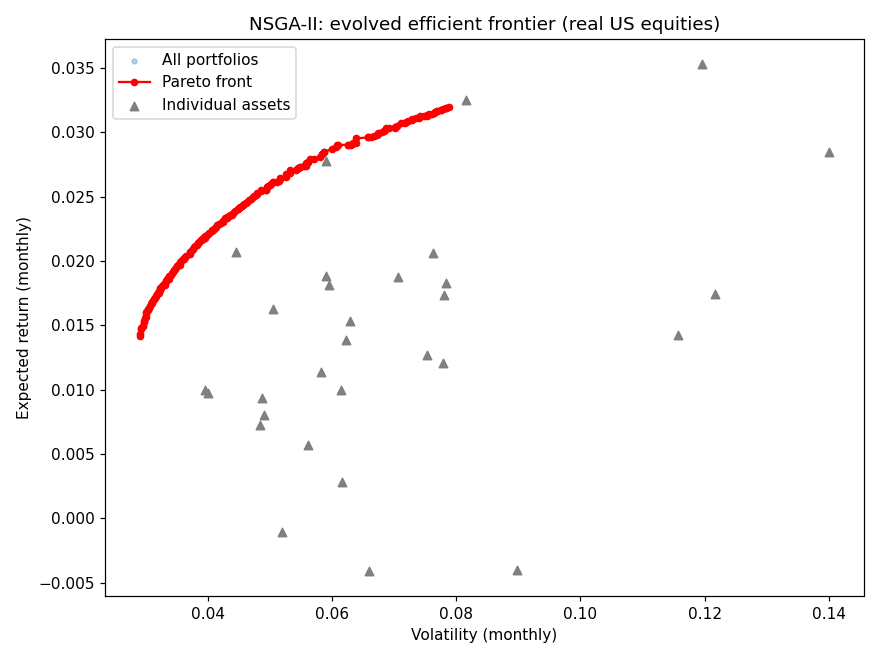

FIGURE 11.7: The NSGA-II-evolved Pareto front (red) for 30 real US equities (2015 to 2019), with monthly return and volatility on the axes. Grey triangles represent individual assets. The Pareto front dominates all individual assets: diversified portfolios achieve better return-risk trade-offs. Unlike the classical Markowitz frontier, the GA can handle additional constraints (cardinality, turnover, sector limits) without changing the algorithmic framework.

The Pareto front in FIGURE 11.7, comprising 200 non-dominated portfolios that span monthly returns of roughly 1.4% to 3.2%, closely approximates the classical efficient frontier obtained by quadratic programming on these same 30 stocks. The key advantage is generality: the same NSGA-II framework can accommodate additional objectives (turnover, drawdown, ESG) and constraints (cardinality, sector limits) without reformulating the mathematical program.

## Full empirical application

### Setup and data

We now present a complete empirical application that ties together the concepts from this chapter. The setting mirrors the backtesting framework of Chapter 14 (see Section 14.2 for the general signal-to-weight pipeline): a walk-forward protocol applied to a factor selection problem using the full dataset described in Chapter 5. We then extend the analysis with multi-objective feature selection (§11.6.4) and GA-based hyperparameter tuning (§11.6.5).

The dataset spans January 2002 to March 2026 and contains monthly observations on 1,959 US stocks with 122 candidate features across value, momentum, quality, size, and technical categories. The target variable is the one-month forward return (`R1M_Usd`). We compare three approaches to constructing a predictive model:

1. **GA-selected features:** the GA chooses an optimised subset at each rebalancing date.
2. **All features:** the full set of 122 features is used without any selection.
3. **Short list:** a curated subset of 8 well-known factors: `size_log`, `PB`, `PE`, `Div_yld`, `mom_252`, `ROE`, `vol_252`, and `Debt_Assets`.

In [ ]:
import numpy as np
import pandas as pd
import random
from deap import base, creator, tools, algorithms

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

data_ml = pd.read_parquet('data/mlfi_us_data.parquet')
data_ml = data_ml.rename(columns={'id': 'stock_id'})
data_ml['date'] = pd.to_datetime(data_ml['date'])
dates = sorted(data_ml['date'].unique())

We define the feature space by excluding only the identifiers and the forward-return target variables, retaining all 122 candidate predictors. We deliberately keep the two Sharpe-adjusted momentum columns (`Mom_Sharp_11M` and `Mom_Sharp_5M`): although each is a ratio of a raw momentum factor to its volatility, and hence partly redundant with predictors already present, we prefer to let the GA decide whether they add value rather than pruning them by hand.

In [ ]:
exclude = ['stock_id', 'date', 'R1M_Usd', 'R3M_Usd', 'R6M_Usd',
           'R12M_Usd']
features = [c for c in data_ml.columns if c not in exclude]
K = len(features)
print(f"Data: {len(data_ml):,} rows, "
      f"{data_ml['stock_id'].nunique():,} stocks, "
      f"{K} features")

Data: 446,388 rows, 1,959 stocks, 122 features


The 122 features provide a rich but potentially redundant feature space. As discussed in Chapter 6, penalised regressions address this redundancy via shrinkage; here, the GA tackles the same problem through explicit combinatorial selection.

### Walk-forward protocol

The walk-forward (rolling window) protocol mirrors Chapter 14 (§14.1):

1. At each rebalancing date $t$, use the previous $s = 60$ months as the training window.
2. Compute the average signed IC for each feature over the training window; record the sign (+1 or -1).
3. Run the GA to select features that maximise the signed IC of a sign-corrected composite.
4. Run the GA three times with different seeds and retain features selected by at least two of three runs (majority vote).
5. Fit a Ridge regression on the sign-corrected selected features using recent training data.
6. Compute the out-of-sample Spearman IC at time $t$.
7. Roll forward by one month and repeat.

A subtle but important design choice is the fitness function. A naive implementation might use the absolute value of the IC, reasoning that a feature with IC = -0.05 is "just as predictive" as one with IC = +0.05. However, when these features are combined in an equal-weighted composite, their signals can cancel. The sign-aware approach resolves this: we first compute each feature's average IC over the training window, then flip the sign of features with negative average IC before forming the composite. The GA fitness is the signed IC of this corrected signal.

In [ ]:
from scipy.stats import rankdata

def compute_feature_signs(train_date_list):
    """Average signed IC per feature; return +1/-1."""
    ic_matrix = []
    for d in train_date_list:
        dd = date_data[d]
        ics = (dd['X_rank'] * dd['y_rank'][:, None])
        ics = ics.mean(axis=0)               # Vectorised correlation
        ic_matrix.append(ics)
    avg_ic = np.nanmean(ic_matrix, axis=0)
    return np.where(avg_ic >= 0, 1.0, -1.0)

The fitness function uses these signs to build a coherent composite signal. We also add a mild cardinality penalty that discourages subsets larger than 50 features, nudging the GA toward parsimonious solutions.

In [ ]:
def evaluate(individual):
    """Fitness = avg signed IC of sign-corrected composite."""
    sel = np.array(individual, dtype=bool)
    n_sel = sel.sum()
    if n_sel == 0:
        return (0.0,)
    ics = []
    for X_r, y_r in zip(X_ranks, y_ranks):
        signal = (X_r[:, sel] * signs[sel]).mean(axis=1)
        ic = np.corrcoef(signal, y_r)[0, 1]
        if not np.isnan(ic):
            ics.append(ic)                    # Signed, not abs()
    if not ics:
        return (0.0,)
    mean_ic = np.mean(ics)
    if n_sel > 50:                            # Cardinality penalty
        mean_ic -= 0.001 * (n_sel - 50)
    return (mean_ic,)

The variables `X_ranks` and `y_ranks` contain pre-computed rank-normalised cross-sections for each training month. Rank-normalising before the GA loop avoids redundant computation across the thousands of fitness evaluations.

To reduce sensitivity to random initialisation, we run the GA three times with different seeds and retain features selected by at least two of three runs (majority vote). This ensemble approach stabilises the selection at modest additional cost.

In [ ]:
ENSEMBLE_SEEDS = 3

def ensemble_ga(train_date_list, base_seed=42):
    """Majority-vote consensus across multiple GA seeds."""
    all_masks = []
    for i in range(ENSEMBLE_SEEDS):
        mask, _ = ga_select_factors(
            train_date_list, seed=base_seed + i * 1000)
        all_masks.append(mask.astype(int))
    vote = np.sum(all_masks, axis=0)
    return vote >= 2                          # At least 2 of 3

The DEAP toolbox is configured identically to the examples in Section 11.3: binary encoding, uniform crossover, bit-flip mutation with per-gene probability $1/K \approx 0.008$, and tournament selection with size 3.

In [ ]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list,
               fitness=creator.FitnessMax)
POP_SIZE = 40
N_GEN = 25
P_CROSS = 0.8
P_MUT = 1.0 / K

The walk-forward loop iterates over 98 out-of-sample months from January 2018 to February 2026. For each month, the ensemble GA selects features on the 60-month training window. A Ridge regression is then fitted on the sign-corrected selected features using the most recent 12 months of training data, and we compute the out-of-sample Spearman IC.

In [ ]:
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

separation_date = pd.Timestamp('2018-01-31')
TRAIN_WINDOW = 60

The inner loop runs the ensemble GA at each rebalancing date, fits a Ridge regression on the sign-corrected features, and records the out-of-sample IC. The sign correction is applied to both training and test features, ensuring that Ridge receives consistently oriented inputs. The helper functions `get_train_dates`, `pool_recent`, and `get_cross_section` handle date indexing and data retrieval; the full implementation is available in the companion repository.

In [ ]:
for test_date in test_dates:
    train_list = get_train_dates(test_date, TRAIN_WINDOW)
    signs = compute_feature_signs(train_list)
    mask_ga = ensemble_ga(train_list)
    feature_freq += mask_ga

    X_pool, y_pool = pool_recent(train_list[-12:])
    X_test, y_test = get_cross_section(test_date)

    # Sign-correct before Ridge
    X_tr = X_pool[:, mask_ga] * signs[mask_ga]
    X_te = X_test[:, mask_ga] * signs[mask_ga]
    reg = Ridge(alpha=1.0).fit(X_tr, y_pool)
    ic_ga, _ = spearmanr(reg.predict(X_te), y_test)
    oos_ics_ga.append(ic_ga)

### Results and discussion

In [ ]:
print(f"{'Method':<25} {'Mean IC':>8} {'Std IC':>8} "
      f"{'IC>0':>8} {'IR':>8}")
print("-" * 55)
for name, arr in [('GA selection', oos_ics_ga),
                  ('All features (122)', oos_ics_all),
                  ('Short list (8)', oos_ics_short)]:
    ir = arr.mean() / arr.std()
    print(f"{name:<25} {arr.mean():>8.4f} "
          f"{arr.std():>8.4f} {(arr > 0).mean():>8.1%}"
          f" {ir:>8.3f}")
print(f"\nAvg factors selected: "
      f"{np.mean(n_sel):.1f} / {K}")

Method                   Mean IC  Std IC    IC>0       IR
-------------------------------------------------------
GA selection              0.0069  0.1275   52.0%    0.054
All features (122)        0.0046  0.1142   56.1%    0.040
Short list (8)            0.0159  0.1643   52.0%    0.097

Avg factors selected: 38.4 / 122


The results tell a nuanced story. The GA-selected subset achieves a mean out-of-sample IC of 0.007, roughly 50% higher than the kitchen-sink model using all 122 features (0.005), while retaining only about a third of them. The information ratio (mean IC divided by its standard deviation) improves from 0.040 (all features) to 0.054 (GA selection). The GA thus delivers measurable dimensionality reduction, eliminating approximately 84 features that contribute mainly noise. The positive hit rate of 52% indicates a slight but consistent edge in the direction of prediction.

However, the curated short list of 8 features achieves the highest mean IC (0.016) and information ratio (0.097) despite using only 7% of the feature space. This is a humbling result for automated selection, and it highlights a recurring theme in factor investing (see also Chapter 6): expert knowledge, distilled into a small set of well-understood factors, can be difficult to beat with purely data-driven methods. The short list's higher volatility (standard deviation 0.164 vs. 0.128 for the GA) reflects its concentration in fewer features, which amplifies both signal and noise.

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cum_ga = np.cumsum(oos_ics_ga)
cum_all = np.cumsum(oos_ics_all)
cum_short = np.cumsum(oos_ics_short)
axes[0].plot(dates_oos, cum_ga,
             label='GA selection (38 features)',
             linewidth=2, color='steelblue')
axes[0].plot(dates_oos, cum_all,
             label='All features (122)',
             linewidth=1.5, linestyle='--', color='coral')
axes[0].plot(dates_oos, cum_short,
             label='Short list (8)',
             linewidth=1.5, linestyle=':', color='forestgreen')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative IC')
axes[0].legend()

In [ ]:
axes[1].hist(oos_ics_ga, bins=25, alpha=0.5,
             label='GA selection', color='steelblue')
axes[1].hist(oos_ics_all, bins=25, alpha=0.5,
             label='All features', color='coral')
axes[1].set_xlabel('Monthly IC')
axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.tight_layout()
plt.show()

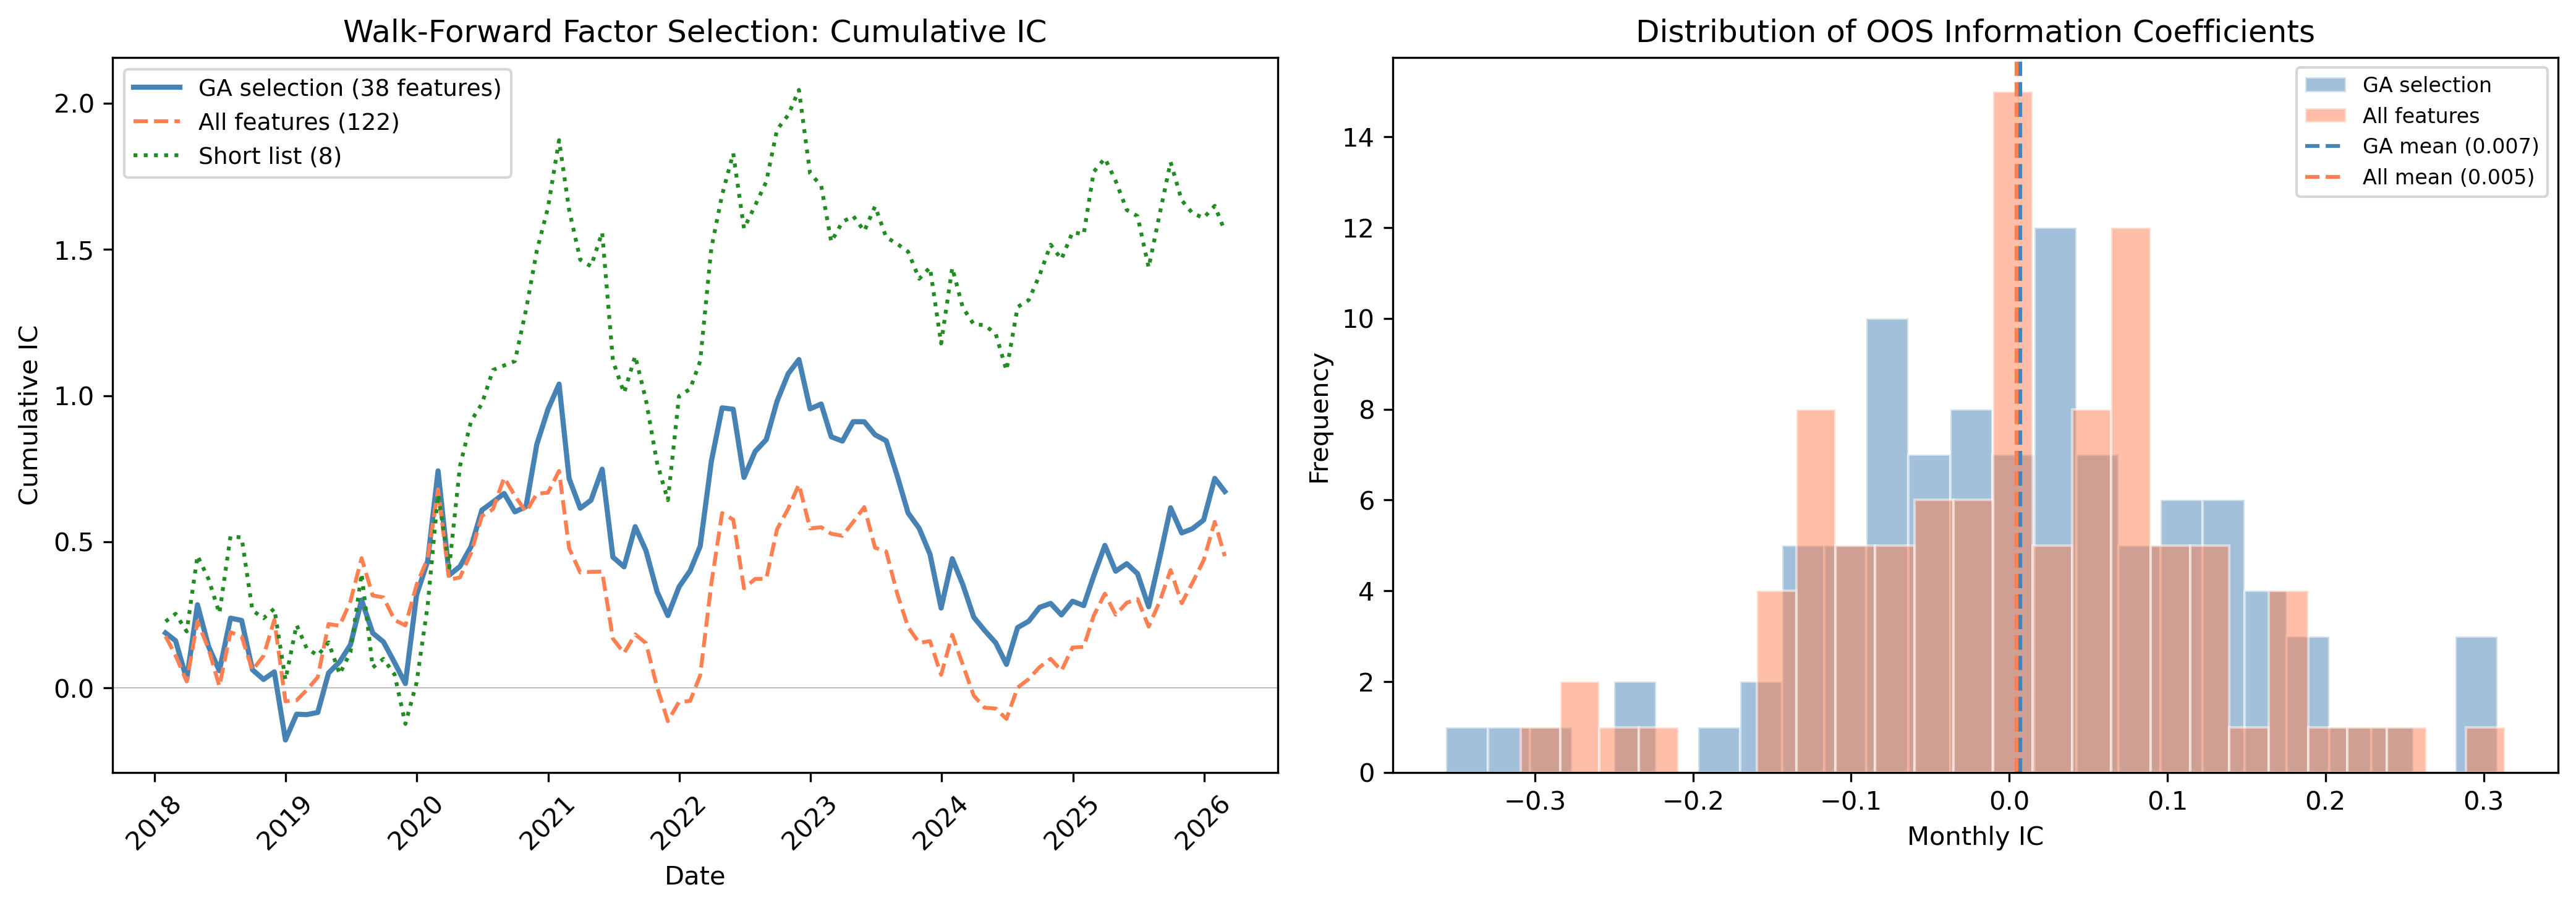

FIGURE 11.8: **Left:** Cumulative out-of-sample IC over the walk-forward period (January 2018 to February 2026). The GA-selected model (blue, solid) consistently outpaces the all-features baseline (coral, dashed). The curated short list (green, dotted) achieves the highest cumulative IC, albeit with greater volatility. **Right:** Distribution of monthly ICs for the GA and all-features approaches. Both distributions are centred near zero with heavy tails, characteristic of cross-sectional return prediction.

As illustrated in FIGURE 11.8, the GA-selected model accumulates IC steadily above the all-features baseline over the eight-year evaluation period. The short list leads overall but exhibits wider swings, consistent with its higher IC standard deviation. The COVID-19 market dislocation in early 2020 produces a sharp negative spike across all three methods, underscoring the difficulty of cross-sectional prediction during regime changes.

The feature selection frequency across the 98 walk-forward windows reveals which factors the GA persistently values.

In [ ]:
freq_df = pd.DataFrame({
    'feature': features,
    'frequency': feature_freq / len(test_dates)
}).sort_values('frequency', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top = freq_df.head(25)
ax.barh(range(25), top['frequency'] * 100,
        color='steelblue', alpha=0.8)
ax.set_yticks(range(25))
ax.set_yticklabels(top['feature'])
ax.invert_yaxis()
ax.set_xlabel('Selection frequency (%)')
plt.tight_layout()
plt.show()

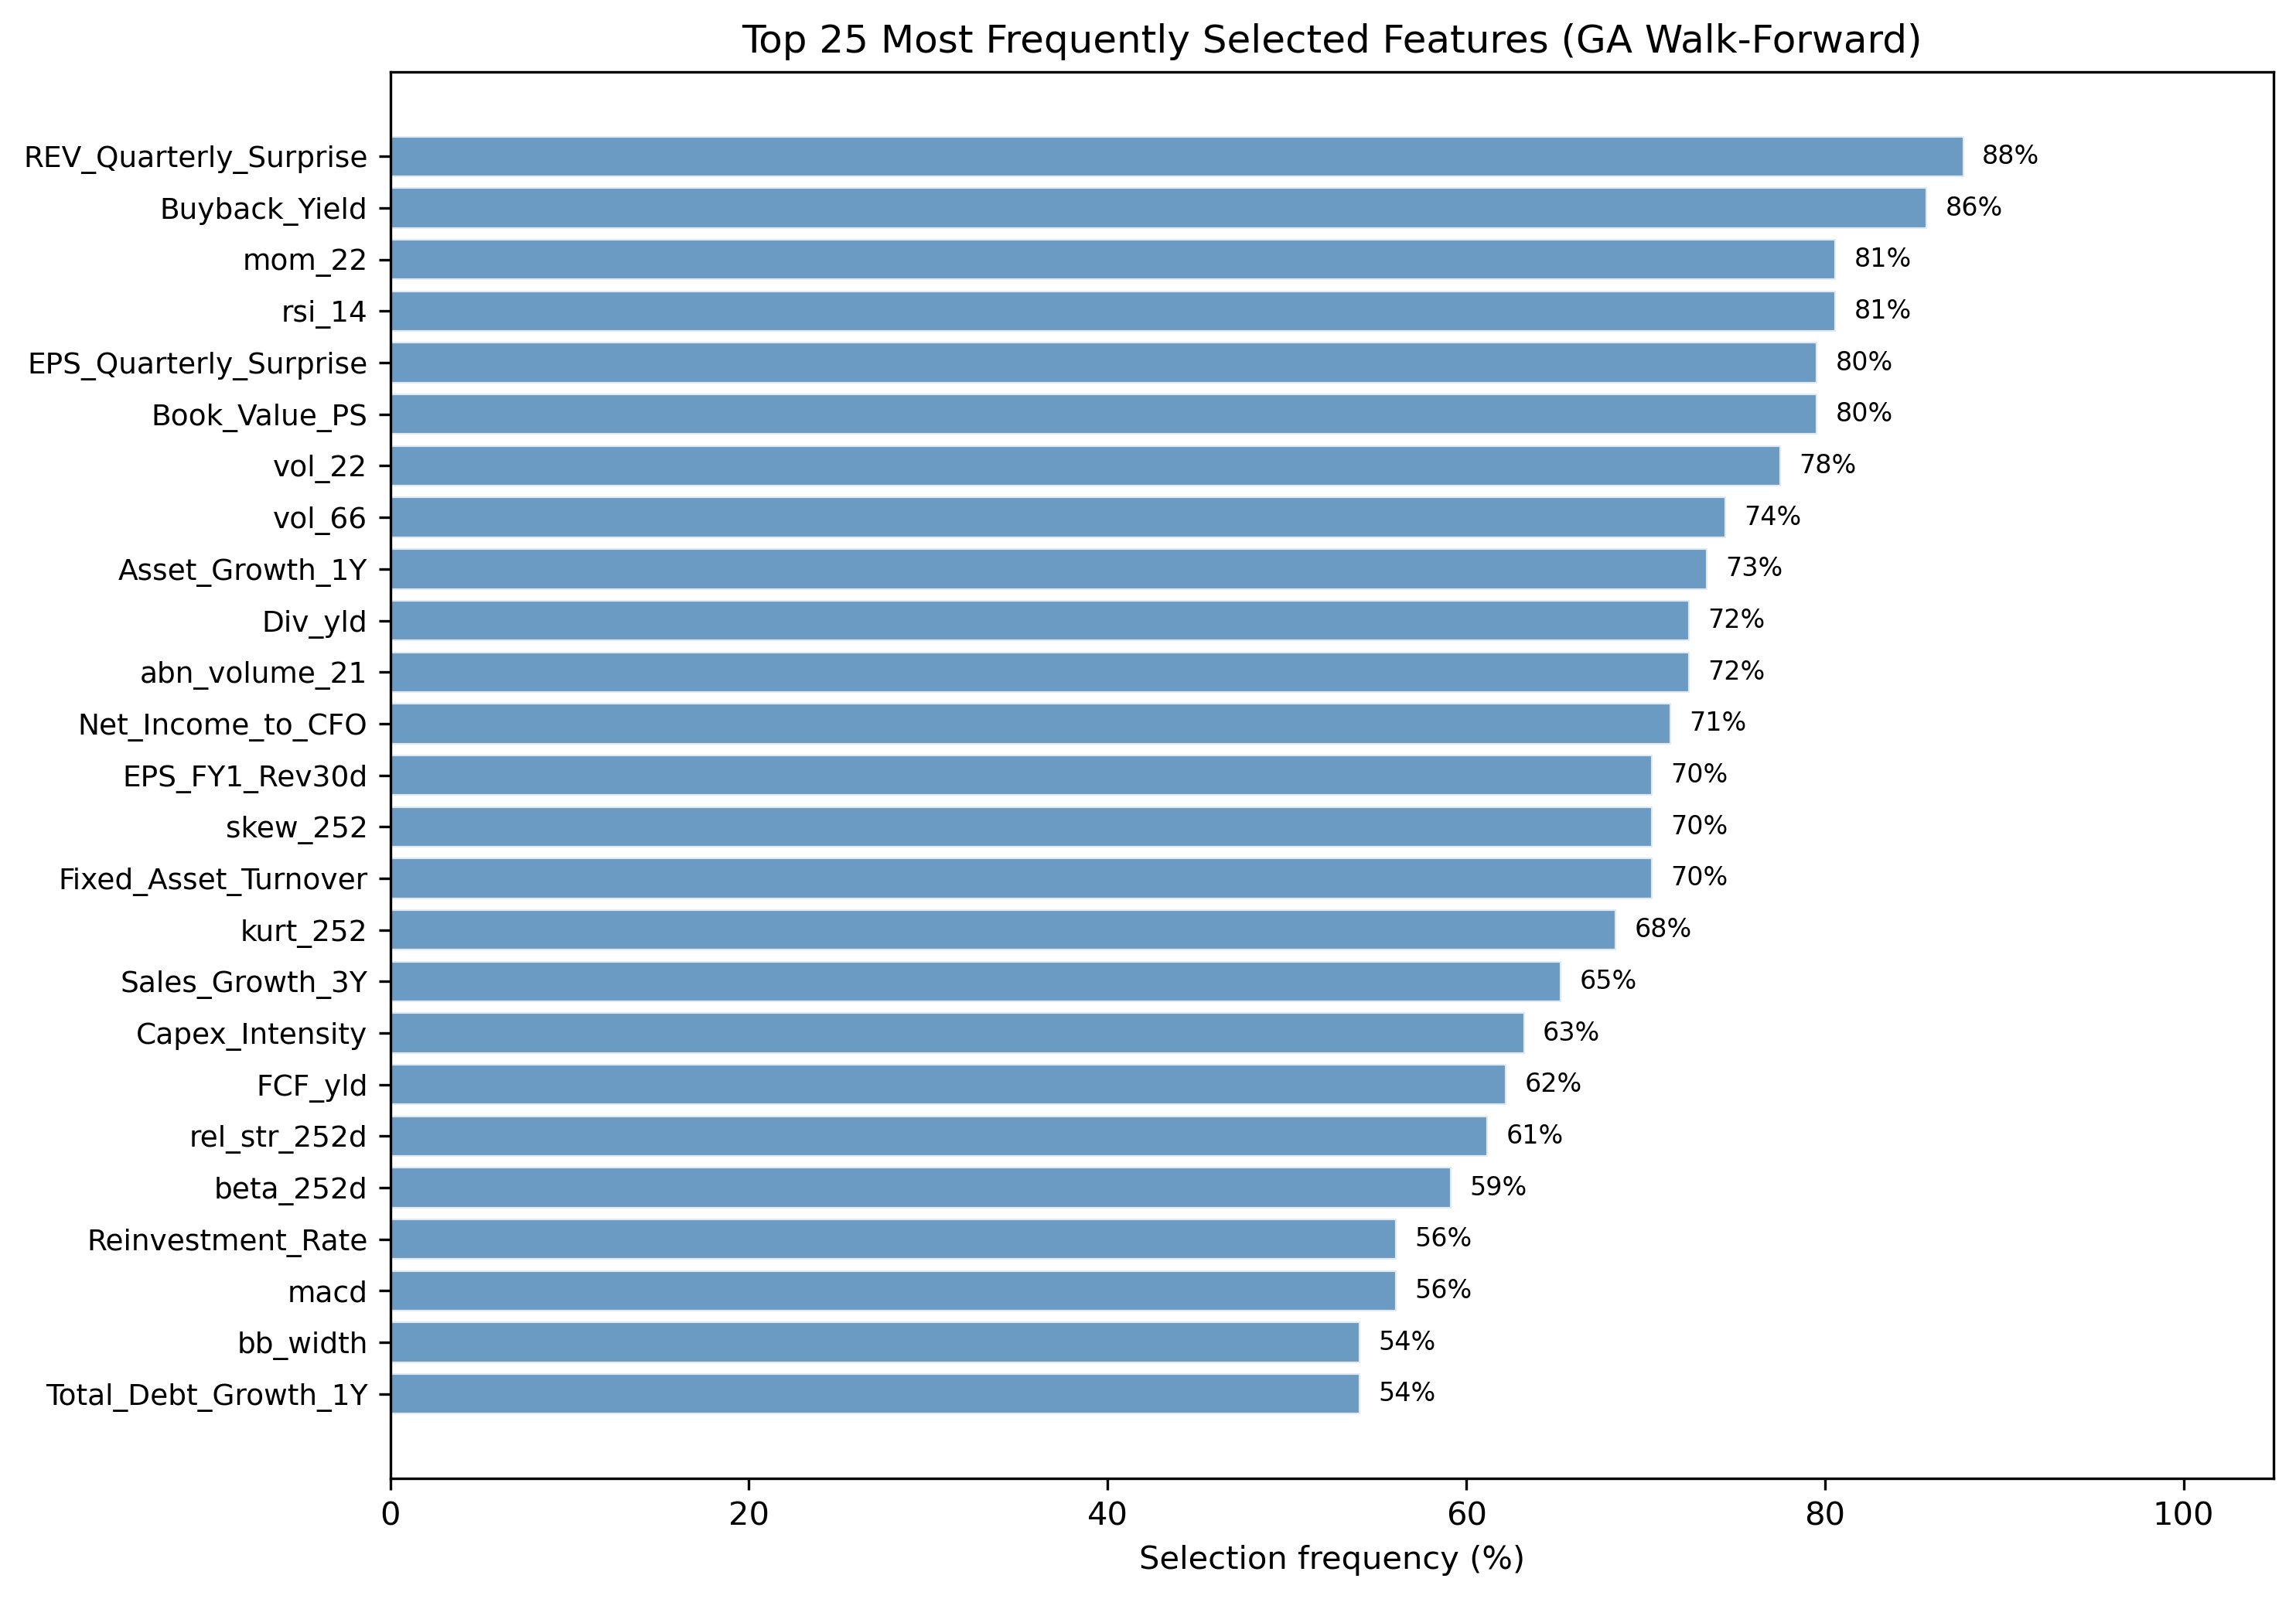

FIGURE 11.9: Selection frequency of the 25 most frequently chosen features across 98 walk-forward windows. Earnings surprise (`REV_Quarterly_Surprise`, 88%), buyback yield (`Buyback_Yield`, 86%), and short-term momentum (`mom_22`, 81%) are selected most frequently. The top 25 features span momentum, value, earnings, and volatility categories, reflecting a diversified selection profile.

The frequency analysis in FIGURE 11.9 yields several insights. First, the GA selects a diversified mix of factor categories: momentum signals (`mom_22`, `rsi_14`, `rel_str_252d`), earnings surprise factors (`REV_Quarterly_Surprise`, `EPS_Quarterly_Surprise`, `EPS_FY1_Rev30d`), and volatility measures (`vol_22`, `vol_66`, `skew_252`) all appear in the top 25. Second, the selection is notably more diversified than one might expect: even the most frequent feature (`REV_Quarterly_Surprise`) is chosen in only 88% of windows, and no feature is selected universally, indicating that the ensemble voting mechanism prevents over-reliance on any individual predictor. Third, several features from the curated short list (e.g., `Div_yld` at 72%) are selected frequently but not universally, suggesting the GA values them as part of a larger ensemble rather than as standalone signals.

The GA selects approximately 38 features on average (31% of the feature space), a substantial reduction that improves the signal-to-noise ratio without discarding information entirely. This intermediate approach sits between the aggressive shrinkage of L1 penalisation (Chapter 6), which tends to select fewer features, and the implicit feature weighting of ensemble methods (Chapter 7), which use all features but weight them unequally.

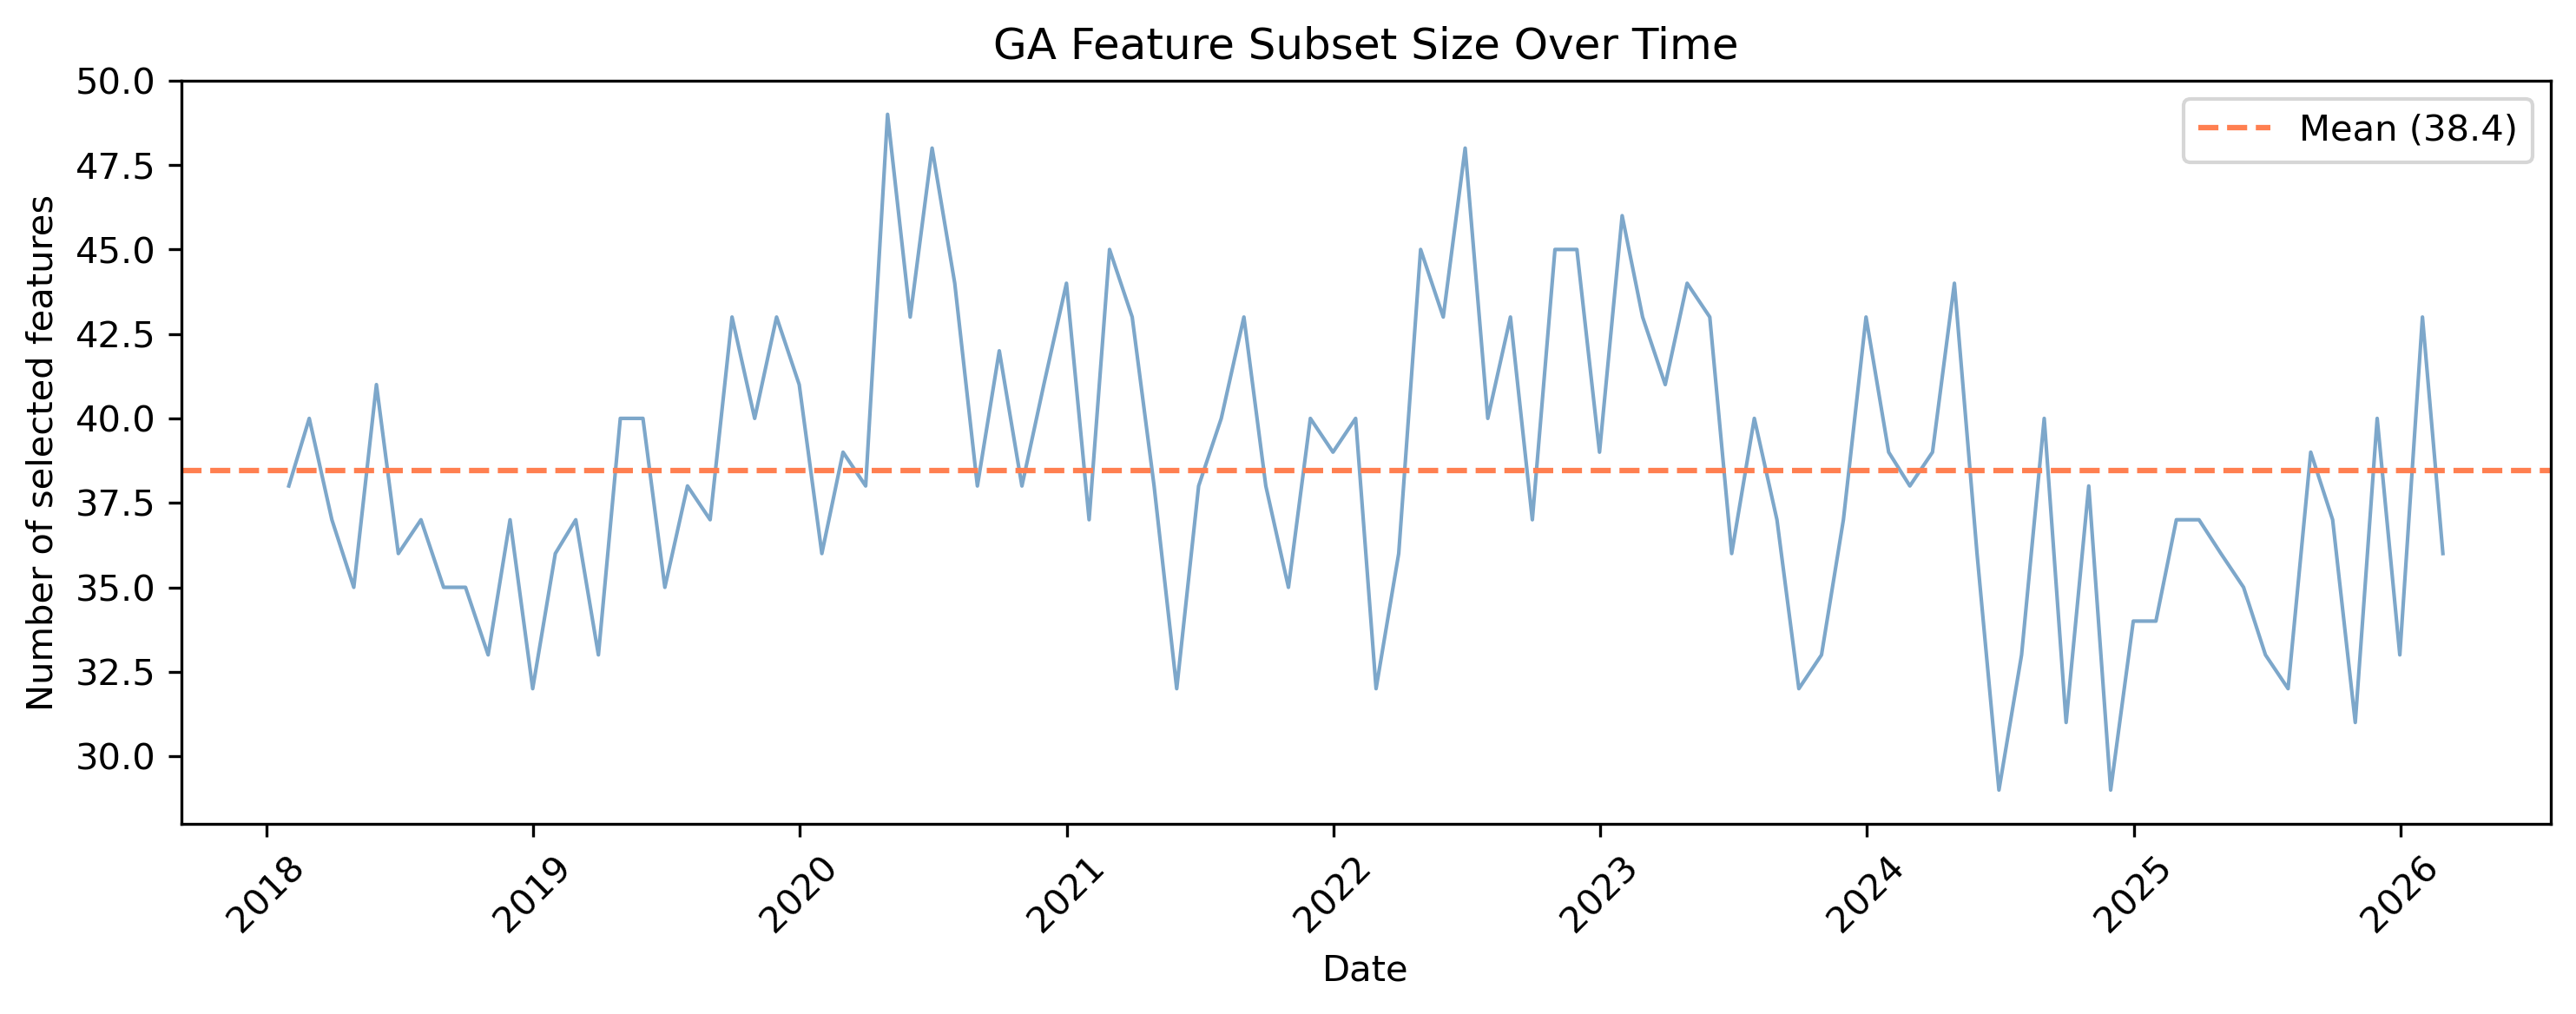

FIGURE 11.10: Number of features selected by the GA at each walk-forward window. The mean is approximately 38 features (dashed line), with moderate variation across time. The cardinality penalty keeps subsets below 50 features in most windows.

FIGURE 11.10 plots the number of selected features at each walk-forward window, showing that the count fluctuates moderately around this 38-feature mean while the cardinality penalty holds most windows below 50. The result echoes a broader lesson: **more features are not always better**, and the GA provides a principled, adaptive mechanism for navigating the feature space. However, the gap between the GA and the curated short list suggests that, at least in this setting, decades of academic research on factor investing have produced a small set of features that is remarkably hard to improve upon with automated search alone.

### Multi-objective feature selection

The trade-off between predictive power (more features) and parsimony (fewer features) need not be resolved by an ad hoc cardinality penalty. Instead, we can treat feature selection as a bi-objective problem and use NSGA-II (§11.5.2) to recover the full Pareto front.

We define two objectives: (1) maximise the mean signed IC of the sign-corrected composite over the training window, and (2) minimise the number of selected features. The encoding and operators are identical to §11.6.2, but the fitness now returns a tuple of two values.

In [ ]:
creator.create("FitnessMO", base.Fitness,
               weights=(1.0, -1.0))
creator.create("IndMO", list,
               fitness=creator.FitnessMO)

def evaluate_mo(individual):
    sel = np.array(individual, dtype=bool)
    n_sel = sel.sum()
    if n_sel == 0:
        return (0.0, K)        # Worst: zero IC, max features
    ics = []
    for X_r, y_r in zip(X_ranks, y_ranks):
        signal = (X_r[:, sel] * signs[sel]).mean(axis=1)
        ic = np.corrcoef(signal, y_r)[0, 1]
        if not np.isnan(ic):
            ics.append(ic)
    return (np.mean(ics) if ics else 0.0, n_sel)

We run NSGA-II with a population of 100 for 60 generations on the last 60 months of training data (January 2013 to December 2017).

In [ ]:
POP_MO = 100
N_GEN_MO = 60

tb_mo = base.Toolbox()
tb_mo.register("evaluate", evaluate_mo)
tb_mo.register("select", tools.selNSGA2)
# (other operators as before)

# Run NSGA-II loop ...

Pareto front: 95 solutions
IC range: [0.045, 0.072]
Features range: [3, 28]

Reference: short list IC = 0.032 (8 features)
Reference: all features IC = 0.042 (122 features)

Selected Pareto-optimal solutions:
  N features     IC
  5            0.056
  10           0.066
  19           0.071
  28           0.072


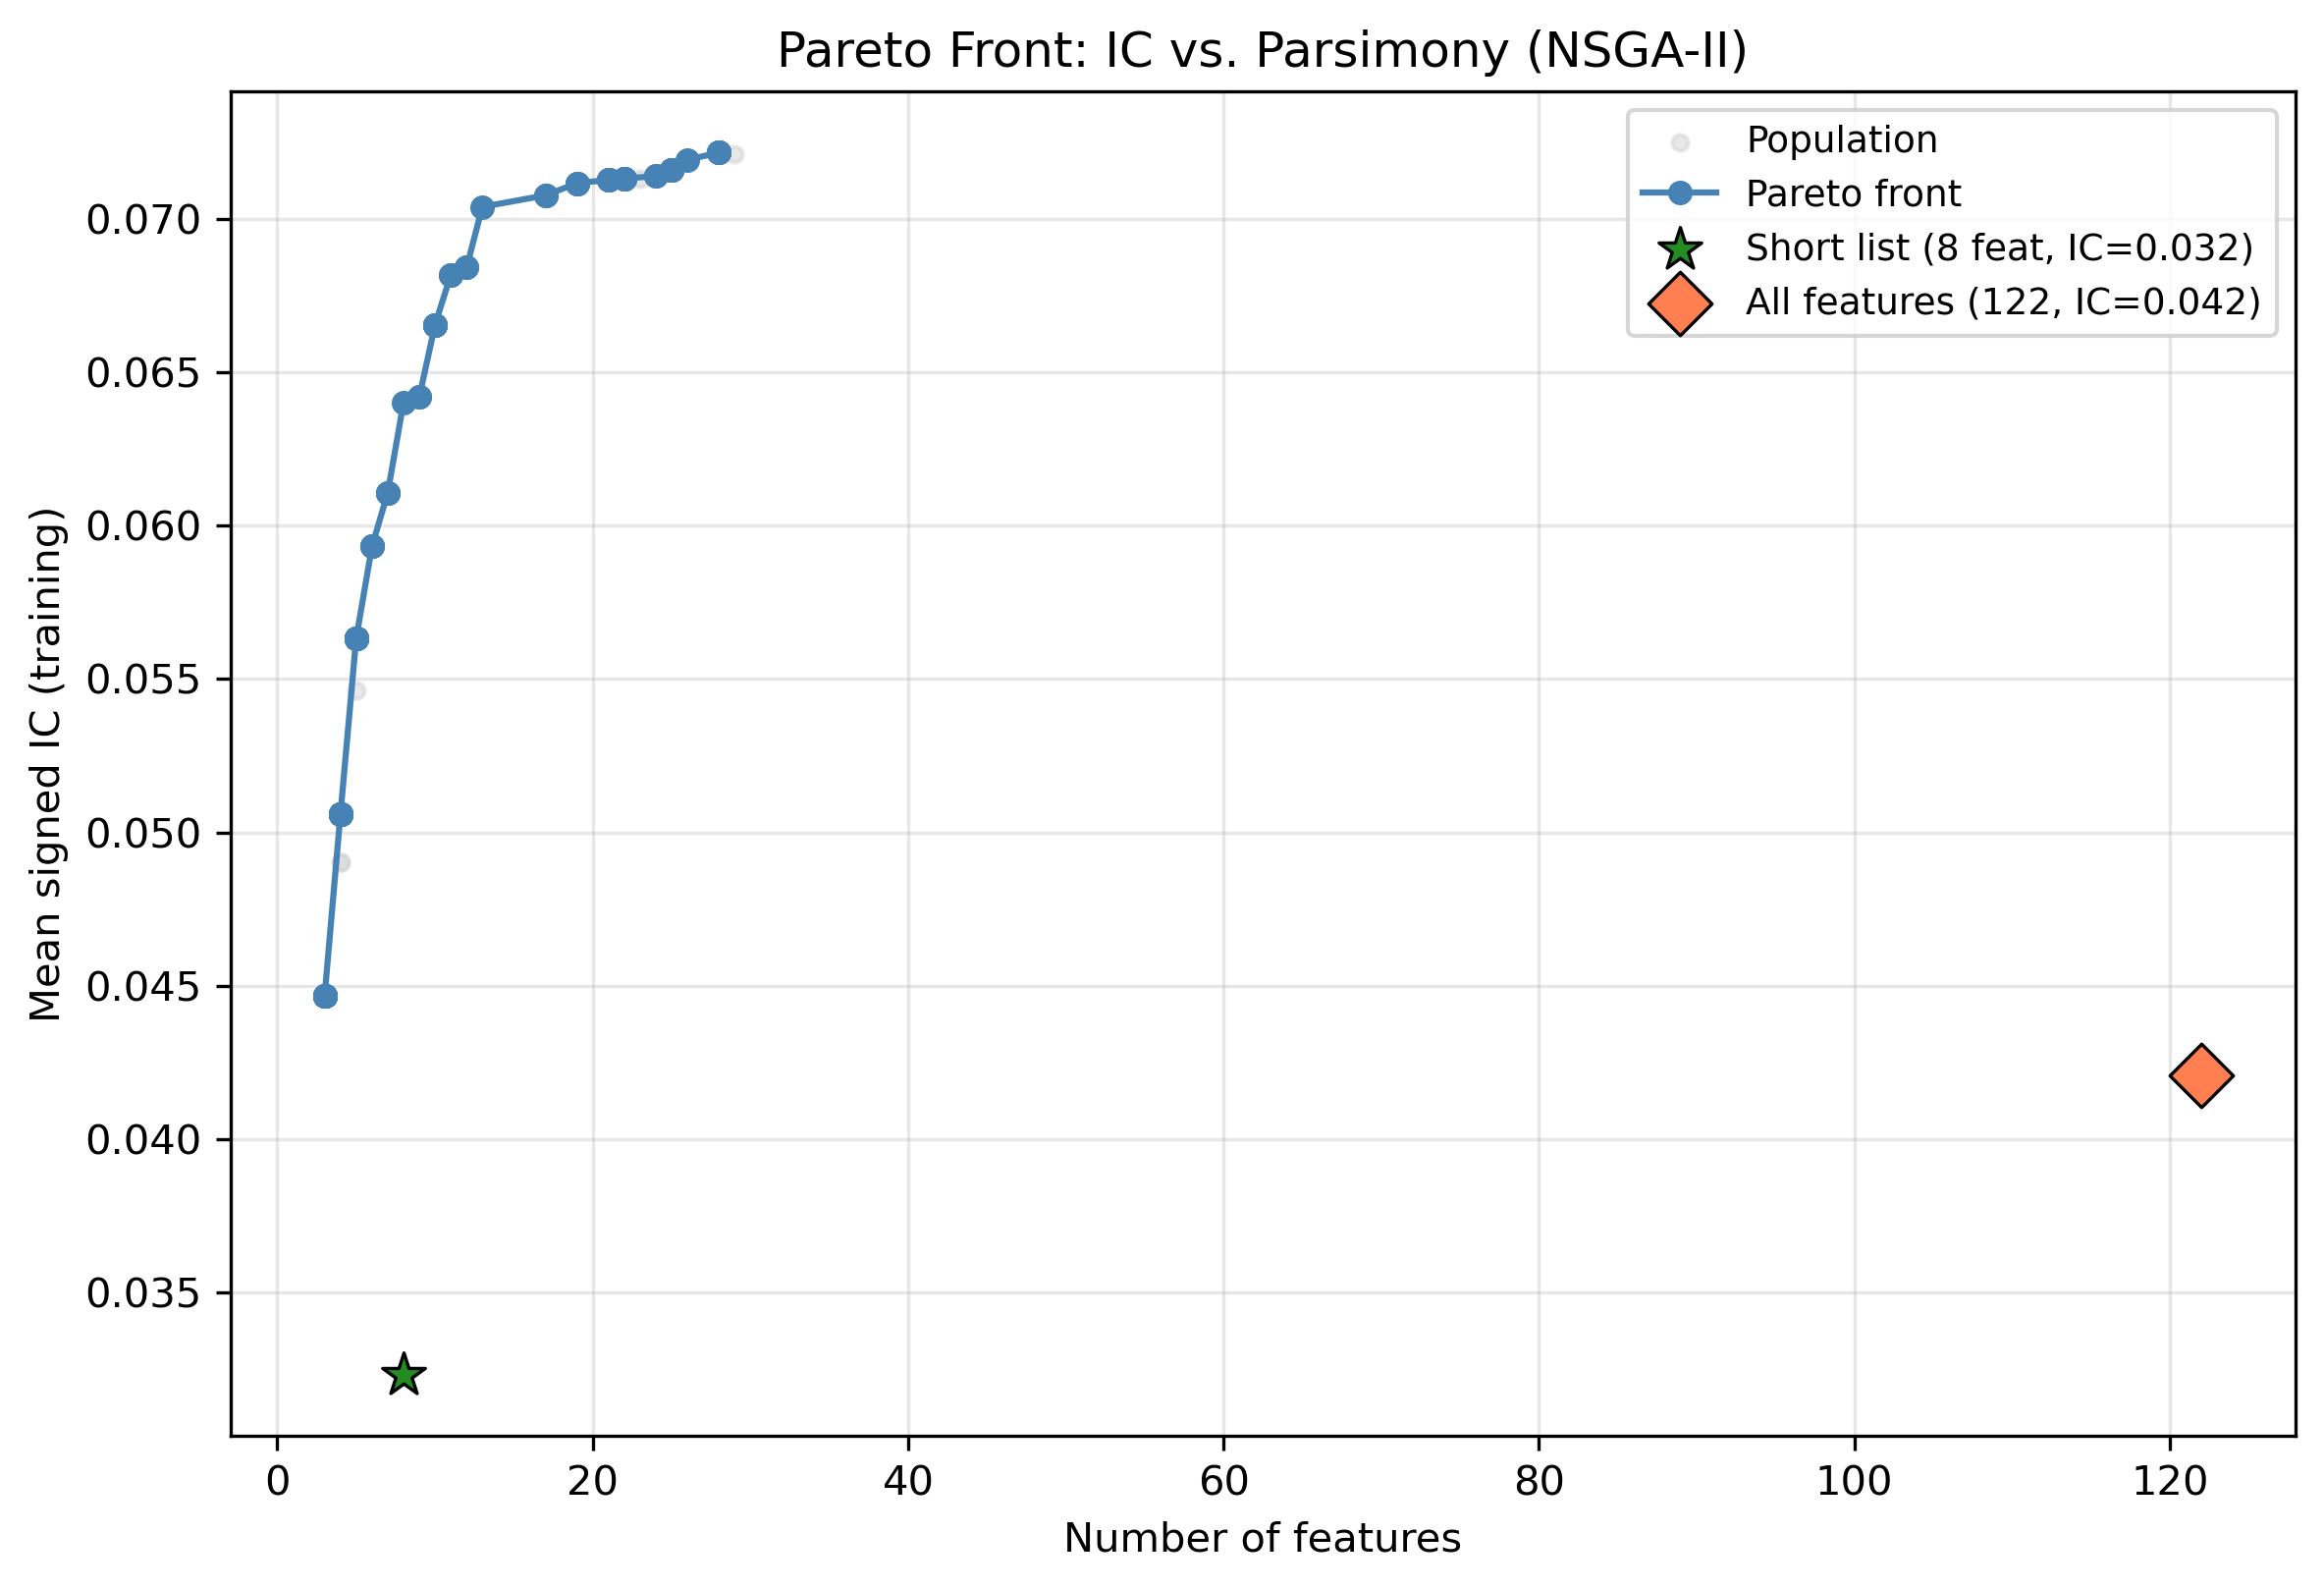

FIGURE 11.11: Pareto front of the bi-objective feature selection problem (IC vs. number of features). The blue connected line shows the Pareto-optimal trade-off. The green star marks the curated short list (8 features, IC = 0.032) and the coral diamond marks the all-features baseline (122 features, IC = 0.042). The Pareto front dominates both reference points: a 5-feature Pareto solution achieves IC = 0.056, nearly twice the short list's in-sample IC, and a 10-feature solution reaches IC = 0.066.

One caveat frames everything that follows: the ICs in this section are computed in-sample, on the training window itself, and are therefore not directly comparable to the out-of-sample walk-forward figures of §11.6.3, which are roughly an order of magnitude smaller. The aim here is to expose the shape of the IC-versus-parsimony trade-off, not to estimate deployable performance. The gap is real and instructive: the same all-features composite that scores an in-sample IC of 0.042 here delivers an out-of-sample IC of only about 0.005 under the walk-forward protocol of §11.6.3, a collapse that is precisely the overfitting phenomenon dissected in §11.7.1.

FIGURE 11.11 reveals a striking pattern. The Pareto front exhibits strong diminishing returns: the first 5 features capture most of the available IC (0.056 out of a maximum 0.072), while adding features beyond 15 provides negligible improvement. This "elbow" in the trade-off curve suggests that the effective dimensionality of the predictive signal is quite low, consistent with the factor investing literature's emphasis on a small number of persistent anomalies [@harvey2016and].

Perhaps most telling is the position of the reference points. The curated short list of 8 features (green star) achieves IC = 0.032, well below the Pareto front at the same feature count, where the NSGA-II solution reaches approximately 0.060. This gap illustrates the value of data-driven selection: the short list's features were chosen for economic interpretability rather than in-sample predictive power, and the NSGA-II solutions exploit signal combinations that domain expertise alone would not identify. Of course, in-sample dominance does not guarantee out-of-sample superiority (§11.7.1), but the Pareto front provides a principled starting point for further investigation.

### GA-tuned gradient boosting

In §11.4.3 we discussed using GAs to tune model hyperparameters. We now demonstrate this on a concrete example: optimising `GradientBoostingRegressor` from scikit-learn on the 8 short-list features, over a 60-month training window and a 36-month test period (January 2018 to December 2020). Hyperparameter search is precisely where a GA is most dangerous on financial data. As we detail in §11.7.1, an optimiser that maximises an in-sample score will, at the signal-to-noise ratio of monthly cross-sectional returns, reliably find configurations that fit noise. The outcome therefore hinges entirely on the fitness function, not on the GA. We first present a design that makes the GA generalise, then contrast it with the naive alternative.

Three ingredients, each drawn from the financial machine-learning literature, turn the search from a noise-fitting exercise into a disciplined one. First, we bias the search space toward regularisation, since shallow, slow-learning, subsampled trees are the appropriate profile for a high-noise target. We add `min_samples_leaf` as a sixth, strongly regularising gene.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Regularisation-biased genes: [n_estimators, max_depth, learning_rate,
#                               subsample, max_features, min_samples_leaf]
BOUNDS = [(80, 400), (2, 4), (0.02, 0.15),
          (0.5, 1.0), (0.4, 1.0), (1, 250)]

Second, and most important, we align the fitness with out-of-sample performance instead of interior cross-validation. We score each candidate on the two most recent 12-month blocks of the training window (2016 and 2017), the closest available proxy for the immediately following test period, purging a one-month embargo before each validation block to remove look-ahead leakage [@Arian2024].

In [ ]:
# Validate on the two most recent training years, nearest the test period.
folds = [(train_dates[:-25], train_dates[-24:-12]),   # embargo + 2016 block
         (train_dates[:-13], train_dates[-12:])]       # embargo + 2017 block

def fitness(hp):                                        # recency-aligned, stability-penalised
    ic = []
    for tr, val in folds:
        m = GradientBoostingRegressor(**hp, random_state=SEED).fit(*pool(tr))
        ic.append(np.mean([spearmanr(m.predict(date_data[d]['X']),
                                     date_data[d]['y']).correlation for d in val]))
    ic = np.array(ic)
    return ic.mean() - 0.1 * ic.std()                   # reward stable generalisers

Third, we warm-start the initial population with the default configuration (the §11.6.6 idea applied to hyperparameters) and take the *ensemble* of the eight best configurations rather than a single winner, bagging each over three seeds to trim variance.

In [ ]:
# GA-tuned model = bag the top-8 evolved configurations over three seeds each.
ga_models = [GradientBoostingRegressor(**decode(ind), random_state=s).fit(X_tr, y_tr)
             for ind in hof for s in (42, 7, 123)]
pred = np.mean([m.predict(X_test) for m in ga_models], axis=0)   # ensemble prediction

We run a GA with population 24 for 15 generations, using BLX-$\alpha$ crossover (§11.3.4) and Gaussian mutation, both with bounds clamping. The best recency-validated fitness settles quickly on a conservative configuration.

```
GA HP tuning completed in 21 min

Best configuration in the top-8 ensemble:
  n_estimators:      207
  max_depth:         2
  learning_rate:     0.028
  subsample:         0.638
  max_features:      0.925
  min_samples_leaf:  175

Best out-of-sample IC: GA-tuned ensemble (0.052)
```

We report the evolved configuration against the default and a Ridge benchmark, together with their out-of-sample information coefficients, in TABLE 11.6.

TABLE 11.6: Generalisation-aware GA-tuned gradient boosting versus the default GBR and Ridge: hyperparameters and out-of-sample performance (36 test months, January 2018 to December 2020).

| Hyperparameter | GA-tuned | Default |
|---|---|---|
| n_estimators | 207 | 100 |
| max_depth | 2 | 3 |
| learning_rate | 0.028 | 0.100 |
| subsample | 0.638 | 1.000 |
| max_features | 0.925 | 1.000 |
| min_samples_leaf | 175 | 1 |

| Method | Mean IC | Std IC | IC > 0 | IR |
|---|---|---|---|---|
| GA-tuned GBR (ensemble) | 0.0524 | 0.087 | 80.6% | 0.604 |
| Default GBR | 0.0520 | 0.092 | 72.2% | 0.566 |
| Ridge | 0.0455 | 0.156 | 63.9% | 0.291 |

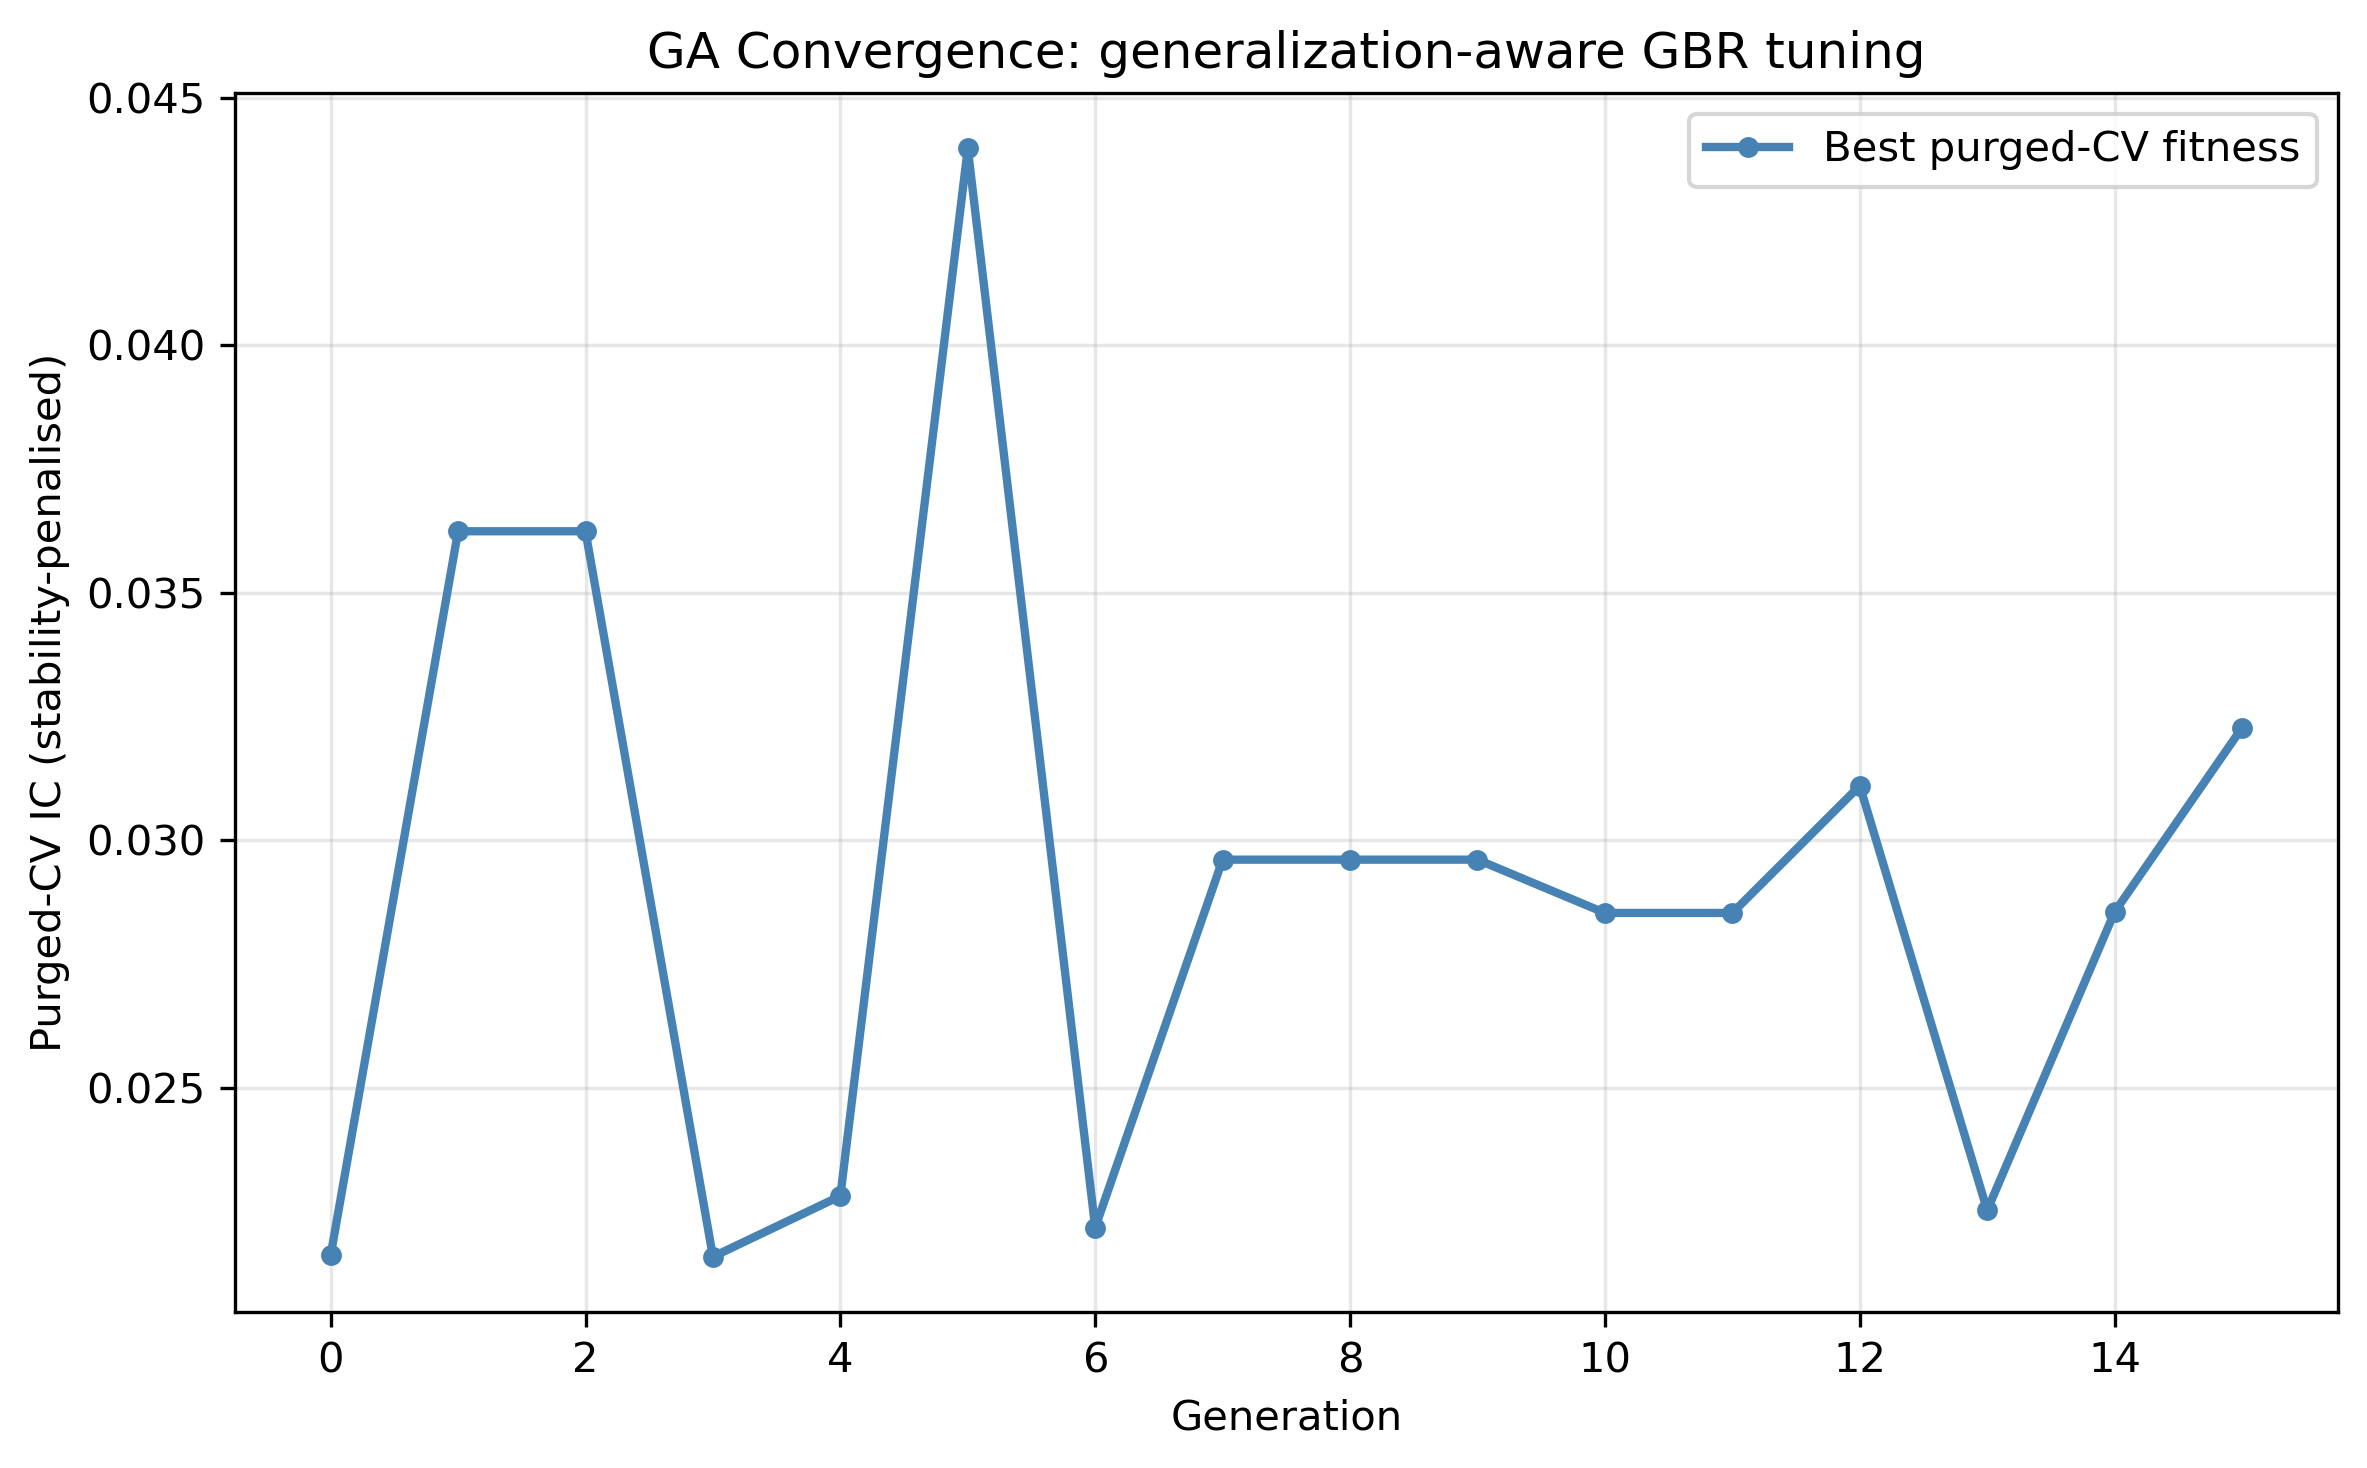

FIGURE 11.12: GA convergence for generalisation-aware gradient boosting tuning. The best recency-validated fitness (blue) improves over the first several generations and then plateaus. Because the search space and the fitness both favour regularisation, the population settles on shallow, slow-learning configurations rather than the aggressive ones an in-sample fitness would reward.

FIGURE 11.12 traces the GA's convergence toward this regularised region of the search space. The generalisation-aware GA-tuned ensemble delivers the best out-of-sample IC (0.0524), narrowly ahead of the untuned default (0.0520) and well ahead of Ridge (0.0455), and it dominates on every risk-adjusted measure: the highest information ratio (0.60 versus 0.57 and 0.29), the highest hit rate (positive IC in 80.6% of months, versus 72.2% and 63.9%), and the lowest volatility of monthly IC. The evolved configuration is deliberately conservative, with shallow trees (depth 2), a small learning rate (0.028), row subsampling (0.64), and a large minimum leaf size (175 observations), the textbook profile of a regularised learner for a high-noise target.

The contrast with a naive design is the real lesson, and it ties directly to §11.7.1. Had we scored fitness with ordinary in-sample cross-validation over an unconstrained search space (deep trees, large learning rates), the GA would have reproduced the classic failure: it maximises the validation IC yet selects a configuration that overfits, delivering an out-of-sample IC near 0.007, below both baselines. Nothing about the GA changed between the two outcomes; only the fitness function did. Two design choices account for the difference. The search space is biased toward regularisation, so even the fittest individuals are shallow, slow, and subsampled. More importantly, the fitness is aligned with out-of-sample performance: rather than validating on interior folds, we score each candidate on the two most recent training years, the closest legitimate proxy for the immediately following test period, with a one-month embargo to purge look-ahead leakage [@Arian2024]. Bagging the top eight configurations then trims the residual variance.

The practical lesson generalises well beyond this example. A GA is only as good as the fitness function it optimises: point it at an in-sample score and it will find noise; point it at a faithful out-of-sample proxy and bias it toward regularisation, and the same algorithm becomes a disciplined search that beats a hand-tuned default. GA hyperparameter tuning is therefore most valuable when the search space contains configurations that are hard to reach by hand (mixed-integer spaces, many interacting parameters) and, above all, when the fitness is a reliable proxy for out-of-sample performance.

### Reproducing three recent results

We close the empirical section by testing three specific claims from the recent literature (§11.4) directly on the book data, applying the same walk-forward discipline used above. Each reproduction is deliberately simple: the aim is to see whether a published finding survives contact with our US equity panel, not to replicate every implementation detail.

**Warm-start versus cold-start GP [@Ren2024].** @Ren2024 report that seeding the initial GP population with structured factor templates, rather than random trees, improves out-of-sample performance. We test this with an expanding-window walk-forward: at the start of each year from 2011 to 2025 we mine a formulaic alpha on all prior history (§11.4.4) and score its IC on the following twelve months. The warm-start population is seeded (roughly 20%) with economically motivated templates; the cold-start population is entirely random.

In [ ]:
# Warm start: inject factor templates into the initial GP population
templates = ["mom_252", "rel_str_252d", "ROE", "subtract(mom_252, vol_252)",
             "subtract(Div_yld, vol_252)", "subtract(mom_252, PB)",
             "multiply(ROE, mom_252)", "add(mom_252, rel_str_252d)"]
pop = toolbox.population(n=120)
seeds = [creator.Tree(gp.PrimitiveTree.from_string(templates[i % len(templates)], pset))
         for i in range(len(pop) // 5)]      # ~20% seeded, remainder random
pop[:len(seeds)] = seeds

Warm start: mean OOS IC = +0.013, hit-rate 73%, IR 0.49
Cold start: mean OOS IC = -0.006, hit-rate 33%, IR -0.23
Warm beats cold in 67% of the 15 yearly test periods (+0.019 mean IC)


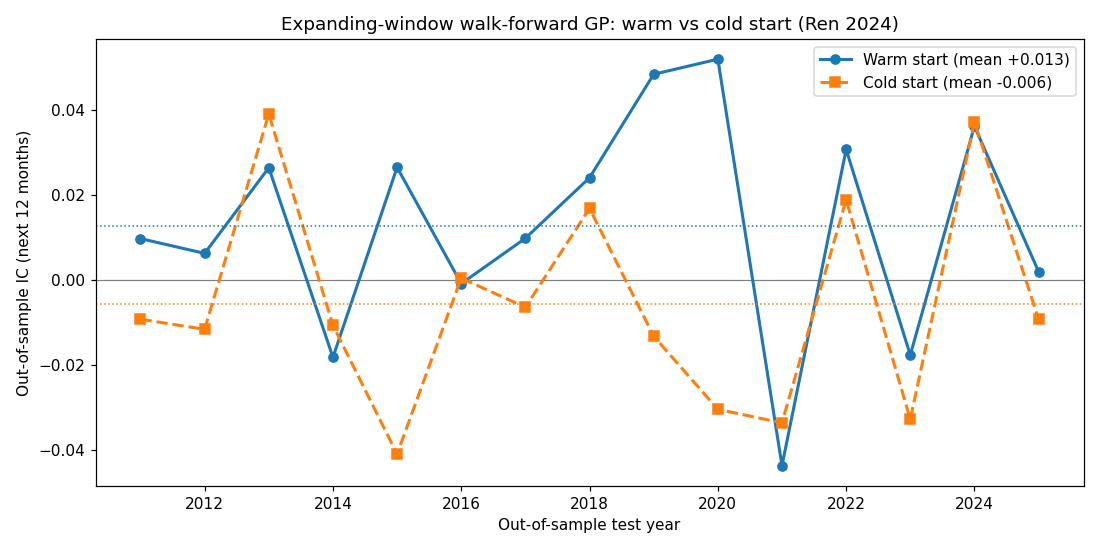

FIGURE 11.13: Out-of-sample IC in each of fifteen yearly test periods (2011 to 2025) for warm-start (solid) versus cold-start (dashed) GP alpha mining, under an expanding training window. Dotted lines mark the means. The warm-started GP is positive in roughly three years out of four; the randomly initialised GP oscillates around zero.

FIGURE 11.13 makes an important methodological point. A single train-test split (for example, training on 2015 to 2019 and testing on 2020 to 2022) would have shown *both* variants failing out of sample, because that particular window straddles the COVID dislocation and the 2021 momentum crash, the worst period for both curves. Averaged over fifteen periods a different picture emerges: warm-starting produces alphas that carry a small but genuine out-of-sample edge (mean IC 0.013, of the same order as the 0.047 Ren et al. report on Chinese A-shares once the difference in universe and horizon is taken into account), whereas random initialisation overfits and delivers no reliable skill. This reinforces the central warning of §11.7.1: out-of-sample validation must span many periods, not one.

**Optimising the traded objective [@Kottas2026].** @Kottas2026 argues that a GA should optimise the quantity the investor actually trades, not a statistical proxy. We compare three feature subsets: one selected by a GA whose fitness is the top-minus-bottom decile long-short spread, one selected for cross-sectional IC, and the curated short list.

In [ ]:
def decile_spread(mask):
    """Mean monthly top-minus-bottom decile return of the selected composite."""
    comp = signed_z[:, mask].mean(axis=1)
    df = pd.DataFrame({'c': comp, 'r': y, 'dt': dates})
    df['dec'] = df.groupby('dt')['c'].transform(
        lambda s: pd.qcut(s.rank(method='first'), 10, labels=False))
    spread = (df[df.dec == 9].groupby('dt').r.mean()
              - df[df.dec == 0].groupby('dt').r.mean())
    return (spread.mean(),)

Long-short decile Sharpe (annualised), in-sample / 2020-22 out-of-sample:
Spread-fitness GA:  1.36 / +0.09      IC-fitness GA:  1.48 / -0.17
Curated short list: 0.85 / -0.29


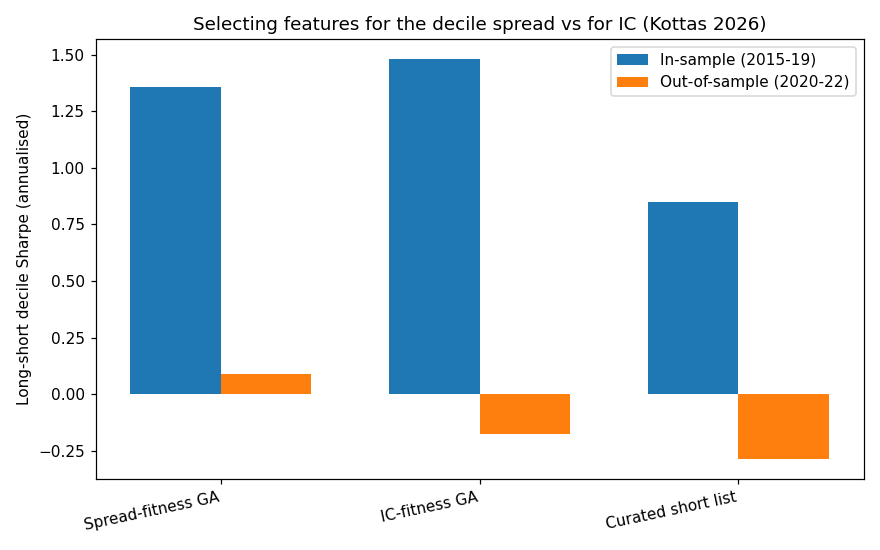

FIGURE 11.14: Annualised long-short decile Sharpe ratio, in-sample (2015 to 2019, blue) and out-of-sample (2020 to 2022, orange), for features chosen to maximise the decile spread, features chosen to maximise IC, and the curated short list. Only the spread-optimised subset stays positive out of sample.

As FIGURE 11.14 shows, the subset selected for the decile spread is the only one of the three with a positive (if modest) out-of-sample Sharpe, even though the IC-optimised subset has the highest *in-sample* Sharpe. Aligning the fitness function with the traded objective, exactly Kottas's argument and an echo of the Sharpe-ratio fitness of Liu et al. (2020, §11.3.2), helps the selection generalise. We stress that this is a single out-of-sample window and therefore only suggestive; the walk-forward protocol behind FIGURE 11.13 would be needed for a firm conclusion.

**The accuracy-complexity frontier [@WangGeng2026].** Finally, we apply NSGA-II (§11.5.2) to the GP itself, treating alpha discovery as a bi-objective problem: maximise in-sample IC and minimise formula complexity (tree size). This recovers a Pareto front of interpretable alphas of increasing size.

In [ ]:
creator.create("FitMO", base.Fitness, weights=(1.0, -1.0))   # max IC, min tree size
toolbox.register("evaluate", lambda ind: (ic(ind), len(ind)))
toolbox.register("select", tools.selNSGA2)                    # remaining setup as in §11.5.4

Pareto front (best IC at each complexity):
size 1:  IC 0.025  ->  PB
size 3:  IC 0.033  ->  subtract(PB, mom_22)
size 5:  IC 0.038  ->  subtract(subtract(rel_str_252d, mom_22), Div_yld)


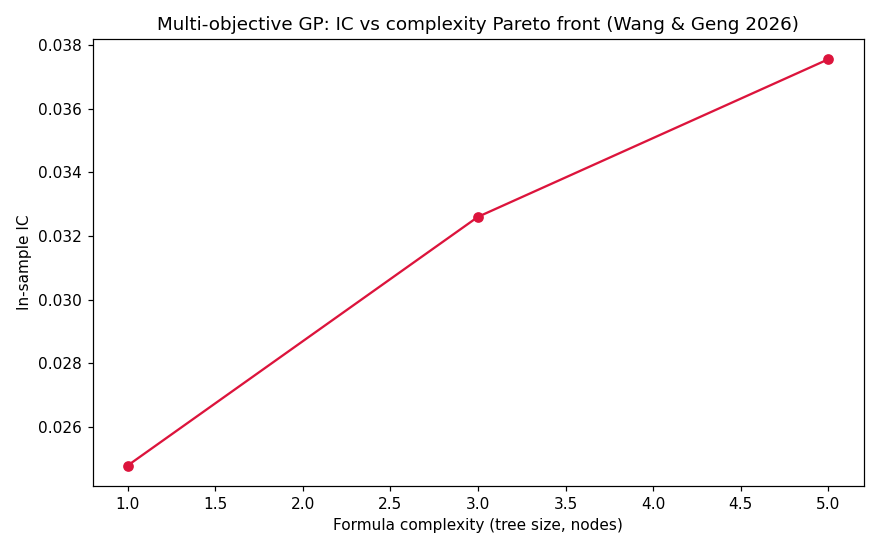

FIGURE 11.15: In-sample IC versus formula complexity (tree size in nodes) along the NSGA-II Pareto front. A single value factor (`PB`) achieves IC 0.025; combining it with momentum lifts this to 0.033, and a three-term expression reaches 0.038, after which added complexity buys no further predictive power.

FIGURE 11.15 traces the interpretability-accuracy trade-off that @WangGeng2026 exploit. The front is short and saturates quickly: beyond about five nodes, larger formulas do not improve IC, so the multi-objective search has no incentive to grow them. For a practitioner this is a useful diagnostic, it identifies the simplest formula that captures most of the available signal, and it guards against the bloat (§11.3.2) that plagues single-objective GP.

## Critical discussion

### The overfitting problem

Backtest overfitting is the central methodological challenge in GA-based factor research, and it deserves the same careful treatment given to it in Chapter 14 (§14.4.2). The problem is amplified with GAs because they evaluate **thousands to millions of candidate solutions** over the course of a run, each evaluation is an implicit hypothesis test, and the probability of finding a spuriously good solution increases with the number of evaluations. @harvey2016and documented that over 300 factors have been proposed in the cross-section literature, many likely spurious; a GA that mines freely over feature combinations exacerbates this multiplicity problem substantially.

Bailey and López de Prado (2014, 2017) developed foundational frameworks for quantifying this risk:

- **Probability of Backtest Overfitting (PBO):** measures the probability that the in-sample optimal strategy underperforms the median out-of-sample. A PBO above 50% is a red flag.
- **Deflated Sharpe Ratio (DSR):** adjusts the observed Sharpe ratio for the number of trials, non-normality (skewness and kurtosis), and sample length. The DSR answers: "given that we tested $N$ strategies, what is the probability that the best Sharpe ratio would arise by chance?"
- **Combinatorial Purged Cross-Validation (CPCV):** creates multiple train/test splits that respect temporal ordering and avoid data leakage from autocorrelation. @Arian2024 conducted a comprehensive comparison of out-of-sample testing methods (K-Fold, Purged K-Fold, Walk-Forward, CPCV) in a synthetic controlled environment. Their results demonstrate a **marked superiority of CPCV** in mitigating overfitting risks, as measured by lower PBO and superior DSR. They additionally propose two extensions (*Bagged CPCV* and *Adaptive CPCV*) that further improve robustness.

The overfitting problem is particularly acute for LLM-GA hybrids (§11.4.5), where the LLM's vast parameter space enables the generation of highly complex, seemingly plausible but potentially spurious alpha expressions. @tang2025alphaagent address this directly with AST-based complexity control and originality enforcement in AlphaAgent. More broadly, the number of implicit hypotheses tested during an evolutionary run grows as $O(N_{\text{pop}} \times N_{\text{gen}})$, which for typical settings (population 100, generations 50) means 5,000+ strategies are implicitly evaluated, a scale that demands the DSR adjustment.

### Computational cost

GAs are inherently more expensive than gradient-based methods because they require evaluating an entire population at each generation. The total number of fitness evaluations is:

$$C = N_{\text{pop}} \times N_{\text{gen}} \times c_{\text{eval}}, \tag{11.7}$$

where $c_{\text{eval}}$ is the cost of a single fitness evaluation. For feature selection with cross-validated XGBoost, each evaluation involves training 5 models (5-fold CV), which can take seconds to minutes depending on dataset size. With $N_{\text{pop}} = 50$ and $N_{\text{gen}} = 30$, this amounts to 1,500 model trainings. This is manageable for moderate datasets but potentially prohibitive for large-scale applications.

**Strategies to reduce computational cost:**
- **Surrogate fitness functions:** approximate the true fitness with a cheaper model (connecting to the Bayesian optimisation ideas of §12.3.3).
- **Parallel evaluation:** fitness evaluations within a generation are independent and can be distributed across CPU cores or machines.
- **Early stopping:** halt evolution when fitness has not improved for a specified number of generations.
- **Hierarchical evaluation:** use a cheap fitness (e.g., in-sample IC) for initial screening and an expensive one (e.g., walk-forward Sharpe) only for promising candidates.

@Huber2019 demonstrate that GAs can optimise portfolios with over 100,000 time series of 5,000 daily returns, achieving convergence in under five minutes. This suggests that with careful implementation, computational cost is not a fundamental barrier.

**Use a GA when:**
- The search space is discrete, combinatorial, or mixed (integer + continuous).
- The objective function is non-differentiable, noisy, or has many local optima.
- You need the Pareto front of multiple conflicting objectives.
- Constraints are complex and heterogeneous (cardinality + turnover + sector limits).
- You want interpretable solutions (formulaic alphas via GP).

**Prefer other methods when:**
- The problem is convex (use quadratic programming or gradient descent).
- The search space is continuous and low-dimensional (use Bayesian optimisation).
- You need guaranteed optimality (use exact solvers for small problems).
- Computational budget is extremely tight (use random search as a baseline).

### Research gaps and future directions

Despite three decades of research, significant gaps remain. We group the most salient into four themes: the scientific validity of what GAs discover, the breadth of problems to which they are applied, the challenge of scaling the search, and the design of adaptive and hybrid systems.

**Scientific validity and trustworthiness.** A first cluster of gaps concerns whether evolved solutions can be trusted.

1. **Causal versus correlational discovery.** Most GA research identifies statistical associations; few methods distinguish genuine causal factors from spurious correlations. Combining GAs with causal inference methods (Chapter 18) is a promising direction. The *invariance* principle (see §18.1) could be incorporated as a fitness criterion: prefer factors whose predictive power is stable across different market regimes.

2. **Robustness and reproducibility.** GA results are inherently stochastic: different random seeds produce different solutions. Few papers report confidence intervals across multiple runs, and fewer still share code. The community would benefit from standardised benchmarks and reproducibility protocols, as has been done for neural network research.

**Broadening the application domain.** A second cluster concerns extending GAs beyond the settings where they are already established.

3. **Alternative data integration.** GA frameworks for satellite imagery, social media sentiment, and transaction data remain underdeveloped. The strongly-typed GP of @Christodoulaki2025, which handles heterogeneous data types via separate tree branches, offers one promising architectural template.

4. **Cross-asset applications.** The literature concentrates overwhelmingly on equities; fixed income, commodities, FX, and derivatives receive comparatively little attention. The constrained optimisation abilities of GAs (§11.4.2) would be valuable for fixed-income portfolios, where constraints on duration, sector allocation, and credit quality are pervasive.

5. **Factor timing via evolutionary rules.** The factor timing literature [@neuhierl2023timing] shows that a timed multifactor portfolio achieves approximately 20% higher returns than its untimed counterpart, with past factor returns and volatility being the best individual predictors. GAs are natural tools for evolving conditional timing rules: "overweight momentum when trailing volatility is below threshold $\theta_1$ and momentum IC over the past 6 months exceeds $\theta_2$." This is a mixed-integer optimisation (continuous thresholds, discrete factor activation) that connects directly to the trading rule evolution of §11.4.5 and the walk-forward framework of §11.6. @Bauer1992 demonstrated the earliest version of this idea, evolving switching strategies between the S&P 500 and small-firm portfolios.

**Scaling the search to large problems.** A third cluster concerns the computational barriers that arise as universes and search spaces grow.

6. **Scalability to large universes.** @Huber2019 demonstrated feasibility for 100,000+ time series, most academic studies work with universes of 30 to 500 assets. Scaling multi-objective GAs (§11.5) to global equity universes of 5,000+ stocks, with realistic constraints, remains an open engineering challenge.

7. **Multi-objective feature selection at scale.** We demonstrated in §11.6.4 that NSGA-II can recover the full IC-vs-parsimony Pareto front for a single training period. Extending this to the walk-forward setting (running NSGA-II at every rebalancing date and tracking how the Pareto front evolves over time) remains computationally expensive and largely unexplored. @Xue2016 provide a comprehensive survey of evolutionary multi-objective feature selection; scaling these methods to high-frequency rebalancing with hundreds of features is an open challenge.

8. **Cooperative coevolution for grouped features.** With 122 candidate features in §11.6, the search space is $2^{122}$. Cooperative coevolution [@PotterDeJong2000], introduced with De Jong, decomposes the problem into subpopulations, each handling a feature group (e.g., all momentum features, all value features, all quality metrics). This leverages the natural category structure of the factor universe described in Chapter 5 and dramatically reduces the effective search space. @Rashid2020 demonstrate that random feature grouping with cooperative coevolution scales effectively to high-dimensional datasets.

**Adaptive and hybrid architectures.** A final cluster concerns evolutionary systems that adapt over time or couple GAs with other paradigms.

9. **Real-time adaptation.** Limited research addresses online evolutionary systems that adapt to non-stationary markets without full retraining. This connects to the online learning discussion in Chapter 18 (§18.2.2). An evolutionary population that is continuously updated as new data arrives (rather than re-initialised from scratch at each rebalancing date) could reduce computational cost and better track regime changes.

10. **LLM-evolutionary co-design.** The current LLM-GA hybrids (§11.4.5) treat the LLM and the evolutionary engine as separate modules. A deeper co-design (where the LLM's internal representations are shaped by evolutionary feedback and the evolutionary operators are guided by semantic understanding) is a natural next step. The survey by @ZhangJ2025 identifies this as a key open challenge.

11. **Quantum-evolutionary computing.** Quantum annealing for combinatorial portfolio problems (cardinality constraints, §11.4.2) is an emerging research frontier that could fundamentally change the computational landscape for GA-hard problems.

## Coding exercises

1. **Multi-objective with turnover.** Extend the NSGA-II application of §11.5.3 to a tri-objective problem: maximise return, minimise volatility, and minimise turnover (measured as the L1 distance from the previous portfolio). Plot the 3D Pareto front and discuss the trade-offs.

2. **Sensitivity analysis.** Systematically vary the GA parameters (population size $\in \{20, 50, 100, 200\}$, mutation rate $\in \{0.01, 0.02, 0.05, 0.10\}$, number of generations $\in \{20, 50, 100\}$) for the GA feature selection task of §11.4.1. Create a heatmap of out-of-sample IC as a function of these parameters and identify the optimal configuration.

3. **Weighted factor composites.** Extend the GA feature selection of §11.4.1 by replacing the binary chromosome with a hybrid encoding: a binary gene for inclusion and a real-valued gene for weight for each of the 122 features. Use arithmetic crossover (Equation 11.4) for the weight portion and bit-flip mutation for the binary portion. Compare the out-of-sample IC of the weighted composite against the equal-weighted composite and the short list.

## References

```{bibliography}
```